# **NYT Crosswords - Skill Evolution**

I have been a diligent solver of the NYT daily crosswords for over 10 years now. 

I was introduced to American style crosswords during my Michigan days with the daily crossword in the Michigan Daily. I subscribed to New York Times and started solving their crosswords in 2016. I was able to solve the early-week puzzles (Mon-Wed) reasonably well but struggled with late-week puzzles. In an attempt to get better at the Fri/Sat themeless puzzles, I started solving some puzzles from the archives.

At some point, this turned into a methodical process where, in addition to solving the day's xword, I would also solve a couple from the archive. And, one fateful day, the thought came unbidden into my head that I should solve _all_ the puzzles available in the archive before my 40th birthday (which was then a couple of years away). And the rest, as they say, is history!!!

Between these archival solves and the daily ones, I now have a dataset of nearly 12,000 solved puzzles. This project is an attempt to track how my crossword solving time has evolved over the years and learn some regression modeling in the process.

Note: Outputs from some of the cells below have been removed because they contain widgets that don't play nicely with Github hosting

<a id="top"></a>

**Contents**

1. [The Modeling Task](#modeling-task)
2. [Data at a Glance](#data)
3. [A Simple OLS Model](#ols)
4. [Mixed-effect Modeling](#mixed)
5. [Bayesian Models](#bayesian)
6. [Model Interpretation](#interpretation)
7. [Compare Models](#compare)
8. [Prediction Breakdown](#breakdown)
9. [Big Takeaways](#takeaways)
10. [What Next](#next)


<a id="modeling-task"></a>

## The Modeling Task

The time it takes for me to solve any given crossword depends on a bunch of different factors.


*   My innate **crossword solving ability** (which is what we are trying to model)
*   **Day of the week**. Monday crosswords are easiest and the difficulty steadily increases through the week with Saturdays being toughest. Sundays are comparable to Thursdays in difficulty (a cool outcome of this exercise is presenting mathematical evidence of this fact) but feature a larger grid
*   **Puzzle fustiness**. Solving a puzzle from 1995 in 2021 introduces some "fustiness". The grid might feature answers that were popular back then but are no longer in vogue. Also, older crosswords were objectively harder (obscure proper nouns, difficult crossings, lots of crosswordese, and tougher cluing overall). For instance, the kind of entries that show up disproportionately in older grids (ESNE, SMEE, ETUI, ADIT, ONAGER ...) has fallen out of favor as editors modernized the fill. Add to that dated proper nouns (bygone actors, defunct brands, Cold-War-era geography such as USSR/SSR/ULAN), references to news cycles long past, and cluing conventions that leaned more on rote trivia and less on the wordplay and misdirection that define modern puzzles. A 1995 grid solved in 2021 is hard on two counts: its vocabulary is stale *and* its cluing plays harder.
*   **Puzzle constructor**. Some constructors are known for their brutal grids while others play easier. But this is a difficult signal to learn because the vast majority of constructors would have been published only a handful of times (often just once)
*   **Puzzle attributes**. How difficult is the fill and the cluing? Are there difficult words, tricky clues, misdirection? This is nearly impossible to quantify and I have some limited proxies for this.
*   **Everything else**!! The signal here is inherently noisy with solve times being impacted by any number of other variables. Maybe I had a headache while solving one day, maybe I knew an obscure, long answer down cold which opened up the entire grid.


We have relatively few parameters and lots of data to estimate them with. Lets try to build interpretable models that can isolate the evolution of my crossword solving ability while controlling for each of these confounding factors.

In [35]:
#@title Install necessary packages
#%pip install -r requirements.txt

import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D
import itertools
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm
from patsy import dmatrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.frameon": False,
})
%matplotlib inline

# ----------------------------------------------------------------------
# Shared constants used across the OLS, mixed-effects and Bayesian sections.
# Defining them once here keeps colours and labels consistent everywhere and
# avoids the copy-paste redundancy of the original per-section notebooks.
# ----------------------------------------------------------------------
PALETTE = {
    "ols":     "#4c72b0",   # blue   - OLS
    "mixed":   "#dd8452",   # orange - mixed effects
    "bayes":   "#55a868",   # green  - Bayesian
    "primary": "#008b8b",   # darkcyan - single-model highlight
    "accent":  "#c44e52",   # crimson
    "muted":   "#708090",   # slategray
    "start":   "#009E73",   # journey-start marker
    "archive": "#D55E00",   # archive-sweep markers
    "pos":     "#c44e52",   # slower than average
    "neg":     "#55a868",   # faster than average
}
day_labels_full = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
                   'Friday', 'Saturday', 'Sunday']

<a id="data"></a>
[&#8593; Back to top](#top)

## Data at a Glance

Load all the puzzle data. There is a small fraction of puzzles that are missing some puzzle features. Remove them and sort the remaining rows by order of date of solving.

In [36]:
#@title Read xword solve times data
df = pd.read_csv("solve_data/DataForModeling_Upto2025.csv")

df['PuzzleDate'] = pd.to_datetime(df['PuzzleDate'], format="%d-%m-%Y", errors='coerce')
df['SolveDate']  = pd.to_datetime(df['SolveDate'],  format="%d-%m-%Y", errors='coerce')

continuous_features = ['AvgWordLen', 'P90ScrabbleScore']
required = ['PuzzleDate', 'SolveDate', 'SolveTime', 'PuzzleDay', 'Constructor'] + continuous_features

before_rows = len(df)
df = df.dropna(subset=required).reset_index(drop=True)
after_rows = len(df)

print(f"Historic data prepared. Dropped {before_rows - after_rows} rows with missing fields.")
print(f"Total historic rows: {after_rows}")

df = df[['PuzzleDate','SolveDate','PuzzleDay','SolveTime','AvgWordLen','P90ScrabbleScore','Constructor']]

Historic data prepared. Dropped 0 rows with missing fields.
Total historic rows: 11661


In [37]:
df.head()

,PuzzleDate,SolveDate,PuzzleDay,SolveTime,AvgWordLen,P90ScrabbleScore,Constructor
0,2016-06-01,2016-06-01,Wednesday,466,4.769231,2.075,Wren Schultz
1,2016-06-02,2016-06-02,Thursday,1062,5.153846,3.000,Susan Gelfand
2,2013-05-16,2016-06-02,Thursday,764,5.175676,2.650,Brendan Emmett Quigley and Elizabeth Donovan
3,2016-06-06,2016-06-06,Monday,328,4.846154,2.130,Mary Lou Guizzo
4,2016-06-05,2016-06-06,Sunday,952,5.152174,2.200,Tom McCoy


### Solve history

This is how my solving journey looks

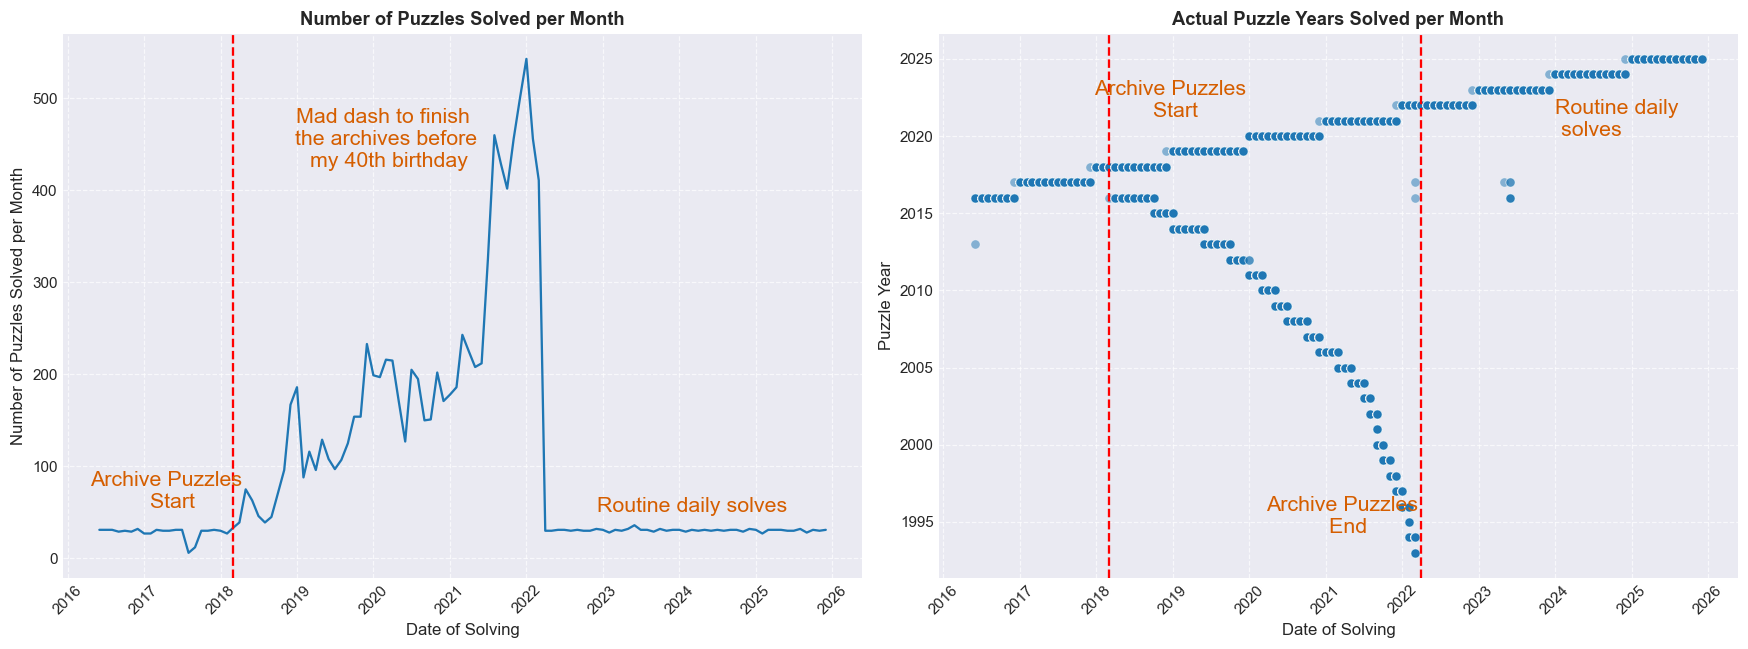

In [38]:
#@title Compute monthly solve statistics
df_temp = df.copy()

# Assign each SolveDate to the beginning of the month
df_temp['MonthStart'] = df_temp['SolveDate'].dt.to_period('M').dt.start_time

# Extract the year from PuzzleDate for calculating average year
df_temp['PuzzleYear'] = df_temp['PuzzleDate'].dt.year

# Group by MonthStart and calculate the number of puzzles and average puzzle year
monthly_stats = df_temp.groupby('MonthStart').agg(
    num_puzzles_solved=('PuzzleDate', 'count'),
    avg_puzzle_year=('PuzzleYear', 'mean')
).reset_index()

plt.figure(figsize=(16, 6))

# Plot 1: Number of Puzzles Solved per Month
ax1 = plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.lineplot(x='MonthStart', y='num_puzzles_solved', data=monthly_stats)
plt.title('Number of Puzzles Solved per Month')
plt.xlabel('Date of Solving')
plt.ylabel('Number of Puzzles Solved per Month')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

# Add annotation
archive_start_date = pd.Timestamp('2018-03-01')
ax1.axvline(x=archive_start_date, color='red', linestyle='--', linewidth=1.5)
ax1.text(archive_start_date - pd.DateOffset(months=10), 50, 'Archive Puzzles \n Start', rotation=0, va='bottom', ha='center', color='#D55E00', fontsize=14)
ax1.text(pd.Timestamp('2020-03-01'), 425, 'Mad dash to finish \n the archives before \n my 40th birthday', ha = 'center', color = '#D55E00', fontsize = 14)
ax1.text(pd.Timestamp('2024-03-01'), 50, 'Routine daily solves', ha = 'center', color = '#D55E00', fontsize = 14)

# Plot 2: Actual Years of Solved Puzzles per Month (Scatter Plot)
ax2 = plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.scatterplot(x='MonthStart', y='PuzzleYear', data=df_temp, alpha=0.5, ax=ax2)
plt.title('Actual Puzzle Years Solved per Month')
plt.xlabel('Date of Solving')
plt.ylabel('Puzzle Year')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

# Add annotations
ax2.axvline(x=archive_start_date, color='red', linestyle='--', linewidth=1.5)
ax2.text(archive_start_date + pd.DateOffset(months=10), 2021, 'Archive Puzzles \n Start', rotation=0, va='bottom', ha='center', color='#D55E00', fontsize=14)
archive_end_date = pd.Timestamp('2022-04-01')
ax2.axvline(x=archive_end_date, color='red', linestyle='--', linewidth=1.5)
ax2.text(archive_end_date - pd.DateOffset(months=12), 1994, 'Archive Puzzles \n End', rotation=0, va='bottom', ha='center', color='#D55E00', fontsize=14)
ax2.text(pd.Timestamp('2024-01-01'), 2020, 'Routine daily \n solves', color = '#D55E00', fontsize = 14)

plt.tight_layout()
plt.show()

You can see the pattern of solving in the plots above. From 2016, I have been solving the day's crossword live (the diagonal line at the top of the second plot). I started solving the archives in March 2018 (red dotted line) and went on till April 2022 going back sequentially in time (hence the monotonically dropping curve between the two dotted lines). In retrospect, this modeling exercise might have been better served had I randomized this archival solve. We will see why later on.

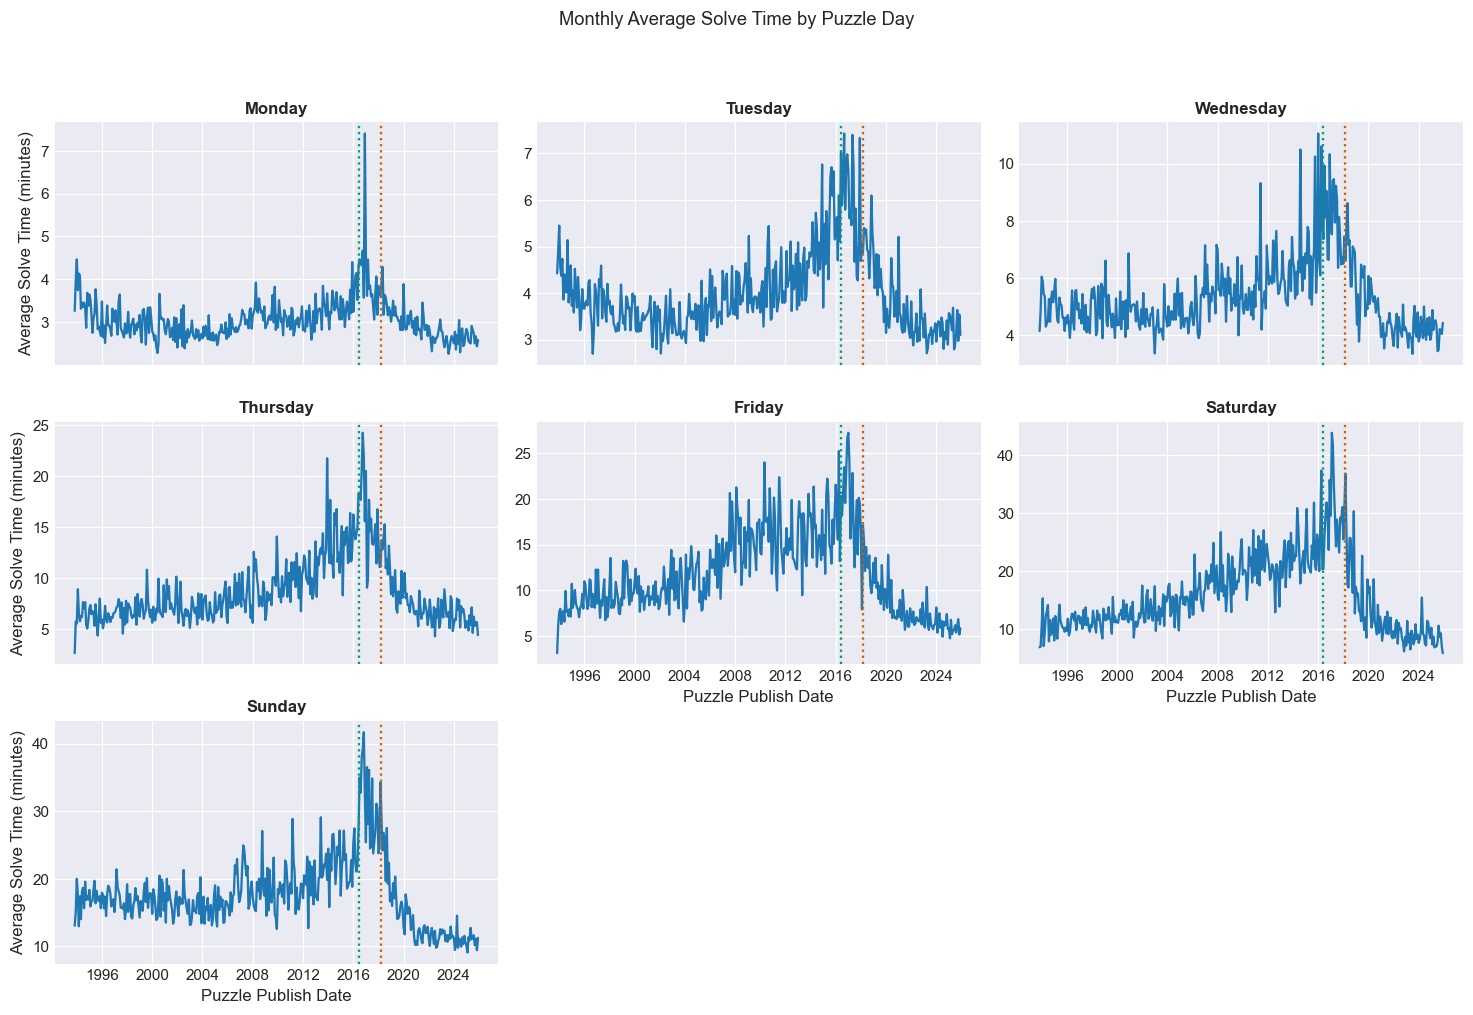

In [39]:
#@title How are my solve times looking?
# Calculate monthly start date from PuzzleDate
df['PuzzleMonthStart'] = df['PuzzleDate'].dt.to_period('M').dt.start_time

# Group by PuzzleMonthStart and PuzzleDay and calculate mean SolveTime
monthly_avg_solve_time = df.groupby(['PuzzleMonthStart', 'PuzzleDay'])['SolveTime'].mean().reset_index()
monthly_avg_solve_time['SolveTime_minutes'] = monthly_avg_solve_time['SolveTime'] / 60 # Convert SolveTime from seconds to minutes

# Define the order of days for consistent plotting
puzzle_day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
monthly_avg_solve_time['PuzzleDay'] = pd.Categorical(monthly_avg_solve_time['PuzzleDay'], categories=puzzle_day_order, ordered=True)

# Create a FacetGrid to plot for each PuzzleDay
g = sns.relplot(
    data=monthly_avg_solve_time,
    x='PuzzleMonthStart',
    y='SolveTime_minutes',
    col='PuzzleDay',
    col_wrap=3, # Wrap columns after 3 plots
    kind='line',
    height=3, aspect=1.5,
    facet_kws={'sharey': False, 'sharex': True}
)

g.set_axis_labels('Puzzle Publish Date', 'Average Solve Time (minutes)')
g.set_titles('{col_name}')
#g.set_xticklabels(rotation=45, ha='right')

# Add vertical dotted line for archive_start_date
xword_start_date = pd.Timestamp('2016-06-01')
for ax in g.axes.flat:
  ax.axvline(x=xword_start_date, color='#009E73', linestyle=':', linewidth=1.5)
  ax.axvline(x=archive_start_date, color='#D55E00', linestyle=':', linewidth=1.5)

plt.suptitle('Monthly Average Solve Time by Puzzle Day', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

This plot shows my average monthly solve times. Note that the y-axis is different for different days reflecting the widely varying difficulty levels across the days. The green dotted line was when I started solving and the red line is when I started going back in time and solving the archives (along with solving the daily puzzles)

We can see that solve times are relatively poor but slowly improving in the initial days (near the green dotted line). From March 2018 (red dotted line), I am solving both forwards in time (every day's puzzle) and backwards in time (going back sequentially into the archive). Gratifyingly, the solve times start going down in both directions.

We can also see that the improvement in solve times is higher in the forward direction than in the backward direction. That means that my improvements are more apparent on the daily solves than on the archival solves. In fact, for Mondays and Tuesdays, the performance even starts deteriorating for pre-2000 puzzles. This is puzzle fustiness in action - I was solving these puzzles in 2021-22 with the benefit of 15 years of archival solves behind me and still found the pre-2000 puzzles significantly harder than puzzles of more recent vintage.

These plots are already telling us that to measure underlying ability, we need to control for day of week and puzzle fustiness.

The table below bears out the same trends in the aggregate as well (note that this includes only daily solves and not the archive solves). The overall average is not particularly meaningful (it will be dominated by the late-week puzzle times) but is still comparable across years.

| **year** | Monday | Tuesday | Wednesday | Thursday | Friday | Saturday | Sunday | Overall |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **2016** | 4:37 | 5:46 | 8:18 | 19:25 | 22:44 | 32:00 | 36:54 | 22:41 |
| **2017** | 3:28 | 5:38 | 8:19 | 16:26 | 18:19 | 35:35 | 32:17 | 21:05 |
| **2018** | 3:46 | 5:31 | 6:53 | 13:20 | 13:43 | 32:24 | 25:55 | 16:15 |
| **2019** | 2:57 | 4:05 | 5:18 | 8:33 | 10:05 | 15:22 | 17:00 | 10:31 |
| **2020** | 2:53 | 3:40 | 5:30 | 7:54 | 9:01 | 14:26 | 14:24 | 8:17 |
| **2021** | 2:55 | 3:28 | 4:14 | 6:27 | 6:58 | 12:06 | 11:57 | 8:04 |
| **2022** | 2:40 | 3:20 | 4:25 | 6:38 | 6:49 | 9:56 | 11:01 | 6:21 |
| **2023** | 2:36 | 2:60 | 3:48 | 5:36 | 7:08 | 10:18 | 11:38 | 6:41 |
| **2024** | 3:02 | 3:04 | 3:49 | 7:06 | 6:45 | 10:25 | 10:34 | 6:49 |
| **2025** | 2:40 | 3:03 | 3:48 | 5:44 | 6:22 | 8:34 | 10:39 | 5:54 |

Note that $2022$ seems like a high-point from this perspective with a plateauing and even a slight degradation beyond that point. It will be curious to see if the models can capture this effect.

<a id="ols"></a>
[&#8593; Back to top](#top)

## A Simple OLS Model

Let us start by building a simple OLS model that captures the basic dynamics of the problem. We will add more complexity to this model as we go on.

### Dependent variable

In this model (and in the models that follow), the dependent variable will be $\log(\text{solve time})$. Thus, all effects we measure will be multiplicative. For instance, Tuesdays will take $X$ times as long (multiplicative) compared to Mondays rather than taking $Y$ minutes longer (additive).

### Feature engineering

The independent variables for our model are day of week (fixed-effect with one dummy per day), whether a given puzzle is an archival solve or not (a single binary indicator), some basic puzzle attributes (more on this below), the publishing year of the puzzle (which is a proxy for fustiness) and the main object of interest, crossword solving ability.

**Puzzle Difficulty**: I found some datasets that provide all the clues and answers for all published NYT crosswords. I used this to devise a couple of metrics that capture a puzzle's difficulty level. The metrics I created are average word length (harder puzzles are likely to have open grids with many long words) and average word rarity. The latter is difficult to measure or even define precisely because crosswords have their own vocabulary and often feature words that are never encountered in the wild. I have chosen to use the scrabble score of a word as a proxy for its "toughness" (which is also questionable because, the presence of a rare letter in a word often opens up the grid since it imposes severe constraints on letters around it) and taking the 90th percentile of scrabble scores across all words of the grid as an attribute of that grid.

**Ability**: We will model ability using cubic splines - these are basis functions with certain desirable properties (continuity, continuous first and second derivates at the knots, linearity beyond the boundary) with uniformly spaced knots. We will model ability as $A(t) = \sum_i \eta_i B_i(t)$ with the basis weights $\eta_i$ estimated as OLS coefficients.

In [40]:
#@title Create features

day_mapping = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
               'Friday': 4, 'Saturday': 5, 'Sunday': 6}

log_solve_time = np.log(df['SolveTime'].values)

# Ability is modelled with a cubic-regression spline of calendar time
ABILITY_SPLINE_DF = 8  # Could eventually be determined using 2026 validation data

reference_date = df['SolveDate'].min()
calendar_time = (df['SolveDate'] - reference_date).dt.days / 365.25

ability_basis_raw = dmatrix(f"cr(t, df={ABILITY_SPLINE_DF}) - 1", {"t": calendar_time}, return_type="dataframe")
ability_basis_design_info = ability_basis_raw.design_info  # keep for reconstructing the curve on a grid later

# Drop one spline column since a natural cubic spline's basis functions sum to exactly 1 in every row
ability_basis = ability_basis_raw.iloc[:, 1:].copy()
ability_basis.columns = [f"ability_spline_{i}" for i in range(ability_basis.shape[1])]

print(f"Ability spline basis: {ability_basis.shape[1]} columns (1 dropped to avoid intercept collinearity), "
      f"calendar time spans {calendar_time.min():.2f} to {calendar_time.max():.2f} years.")
print("---"*20)

# Day of Week
day_dummies = pd.get_dummies(df['PuzzleDay'], prefix='day').astype(float)
day_dummies = day_dummies.drop(columns=['day_Monday'])
day_dummies = day_dummies[[f"day_{d}" for d in day_mapping if d != 'Monday']]  # fix column order
print(f"Day dummies: {list(day_dummies.columns)}")
print("---"*20)

# Fustiness (piecewise-linear hinge, same knots as the Bayesian model)
FUSTY_KNOT_RECENT = 2018   # no penalty at/after this year since puzzles are essentially modern
FUSTY_KNOT_OLD = 2010      # Puzzles get noticeably older prior to this point
publish_year = df['PuzzleDate'].dt.year.values.astype(float)
fustiness_terms = pd.DataFrame(index=df.index)
fustiness_terms['gap_since_recent_knot'] = np.maximum(0.0, FUSTY_KNOT_RECENT - publish_year)
fustiness_terms['gap_since_old_knot'] = np.maximum(0.0, FUSTY_KNOT_OLD - publish_year)
print('Sample fustiness terms:')
print(fustiness_terms.head())
print("---"*20)

# Puzzle attributes (AvgWordLen, P90ScrabbleScore)
attribute_terms = df[continuous_features].copy()
print('Sample puzzle attribute terms:')
print(attribute_terms.head())
print("---"*20)

# Indicator for archival solving
solve_lag_days = (df['SolveDate'] - df['PuzzleDate']).dt.days.values
ARCHIVE_LAG_THRESHOLD_DAYS = 30  # Except for archives, I solved puzzles on the same day or a day or two later
is_archive_solve = (solve_lag_days > ARCHIVE_LAG_THRESHOLD_DAYS).astype(int)
archive_terms = pd.DataFrame(index=df.index)
archive_terms['is_archive_solve'] = is_archive_solve.astype(float)
print(f"{is_archive_solve.sum()} / {len(is_archive_solve)} historic rows flagged as archive solves "
      f"(lag > {ARCHIVE_LAG_THRESHOLD_DAYS} days).")
print("---"*20)


Ability spline basis: 7 columns (1 dropped to avoid intercept collinearity), calendar time spans 0.00 to 9.58 years.
------------------------------------------------------------
Day dummies: ['day_Tuesday', 'day_Wednesday', 'day_Thursday', 'day_Friday', 'day_Saturday', 'day_Sunday']
------------------------------------------------------------
Sample fustiness terms:
   gap_since_recent_knot  gap_since_old_knot
0                    2.0                 0.0
1                    2.0                 0.0
2                    5.0                 0.0
3                    2.0                 0.0
4                    2.0                 0.0
------------------------------------------------------------
Sample puzzle attribute terms:
   AvgWordLen  P90ScrabbleScore
0    4.769231             2.075
1    5.153846             3.000
2    5.175676             2.650
3    4.846154             2.130
4    5.152174             2.200
------------------------------------------------------------
8222 / 11661 his

In [41]:
#@title Fit model

X = pd.concat([ability_basis, day_dummies, fustiness_terms, attribute_terms, archive_terms], axis=1)
X = sm.add_constant(X)

ols_model = sm.OLS(log_solve_time, X).fit(cov_type="HC3")
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.820
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     3615.
Date:                Sat, 05 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:27:09   Log-Likelihood:                -2582.9
No. Observations:               11661   AIC:                             5204.
Df Residuals:                   11642   BIC:                             5344.
Df Model:                          18                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     4.40

The coefficients are largely along expected lines.

**Ability splines**: Reassuringly, the splines all have negative coefficients (which implies that ability has a subtractive effect on solve times, i.e., ability improves with time).

**Day of Week**: Days get progressively difficult as is expected. They let us conclude broad patterns - for example, all else being equal, we can conclude that it takes me $e^{0.2398} -1 = 27\%$ longer to finish a Tuesday puzzle compared to a Monday puzzle. This aligns reasonably well with the raw numbers from the dataset as the table below shows.

| Day of Week | Average Solve Time | Index wrt Monday | $\exp({\text{Coeff}})$ |
| :---: | :---: | :---: | :---: |
| **Monday** | 3:04 | 1.0 |  |
| **Tuesday** | 4:00 | 1.306 | 1.271 |
| **Wednesday** | 5:19 | 1.734 | 1.650 |
| **Thursday** | 8:39 | 2.824 | 2.457 |
| **Friday** | 11:45 | 3.836 | 2.911 |
| **Saturday** | 15:45 | 5.142 | 3.793 |
| **Sunday** | 17:40 | 5.769 | 4.958 |

The coefficients are roughly in the right ballpark but there are differences which widen with day of week. This is because there are other variables in the system (puzzle attributes) that soak up some of the variance of those solves.

**Puzzle Attributes**: Both coefficients are positive which makes sense. Puzzles with longer and/or rarer words are harder to complete.

**Is Archive Solve**: All else being equal, archive puzzles take around $e^{0.1699} - 1 = 18.5\%$ longer to solve. Note that this is an intercept effect that applies equally across all archive puzzles. We hoped for more fine grained control ("fustiness increases with puzzle age") from the fustiness terms but unfortunately...

**Fustiness** doesn't seem to work well. Both coefficients are insignificant and have relatively small effect. More on this below.

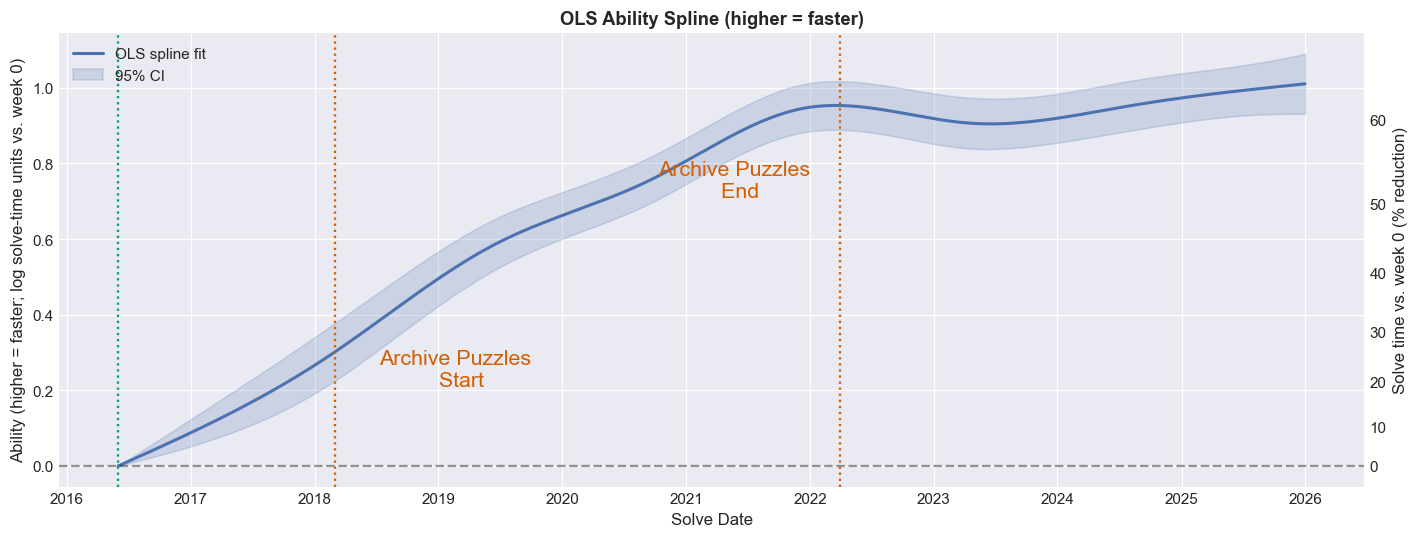

(<Figure size 1430x550 with 1 Axes>,
 <Axes: title={'center': 'OLS Ability Spline (higher = faster)'}, xlabel='Solve Date', ylabel='Ability (higher = faster; log solve-time units vs. week 0)'>)

In [42]:
#@title Visualize OLS Model Findings - Ability

def linear_combo_with_se(model, basis_df, param_names):
    """Mean and SE of basis_df @ beta[param_names], accounting for the
    covariance between those coefficients. Exact for a linear combination of
    OLS (or MixedLM fixed-effect) parameters."""
    beta_subset = model.params[param_names].values
    cov_subset = model.cov_params().loc[param_names, param_names].values
    mean = basis_df.values @ beta_subset
    var = np.einsum('ij,jk,ik->i', basis_df.values, cov_subset, basis_df.values)
    return mean, np.sqrt(np.clip(var, 0, None))


# Smooth calendar grid + spline basis. Built ONCE here and reused by the
# mixed-effects ability plot (the original notebook rebuilt this verbatim).
t_grid = np.linspace(calendar_time.min(), calendar_time.max(), 300)
date_grid = reference_date + pd.to_timedelta(t_grid * 365.25, unit='D')
_ability_grid_basis = dmatrix(ability_basis_design_info, {"t": t_grid},
                              return_type="dataframe").iloc[:, 1:]
_ability_grid_basis.columns = ability_basis.columns


def ability_from_splines(model):
    """(mean, se) of the ability curve for an OLS / MixedLM fit.
    Sign is flipped so that 'faster' reads as higher ability."""
    mean, se = linear_combo_with_se(model, _ability_grid_basis, list(ability_basis.columns))
    return -mean, se


def plot_ability_curve(dates, mean, lo, hi, title, label, color, annotate=False):
    """Shared ability-trajectory plot (used for OLS, mixed effects and Bayesian).
    Adds a right-hand axis showing the day-independent % reduction in solve time,
    1 - exp(-ability). It is multiplicative, so it does NOT depend on the day of
    week -- absolute minutes saved would."""
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(dates, mean, color=color, lw=2, label=label)
    ax.fill_between(dates, lo, hi, color=color, alpha=0.2, label="95% CI")
    ax.axhline(0, color='black', linestyle='--', alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel("Solve Date")
    ax.set_ylabel("Ability (higher = faster; log solve-time units vs. week 0)")
    # Right axis: day-independent % reduction in solve time = 1 - exp(-ability).
    _to_pct = lambda a: 100.0 * (1.0 - np.exp(-np.asarray(a, dtype=float)))
    _from_pct = lambda s: -np.log(1.0 - np.clip(np.asarray(s, dtype=float), None, 99.9) / 100.0)
    secax = ax.secondary_yaxis('right', functions=(_to_pct, _from_pct))
    secax.set_ylabel("Solve time vs. week 0 (% reduction)")
    if annotate:
        ax.axvline(x=xword_start_date, color=PALETTE['start'], linestyle=':', linewidth=1.5)
        ax.axvline(x=archive_start_date, color=PALETTE['archive'], linestyle=':', linewidth=1.5)
        ax.axvline(x=archive_end_date, color=PALETTE['archive'], linestyle=':', linewidth=1.5)
        ax.text(archive_start_date + pd.DateOffset(months=12), 0.2, 'Archive Puzzles \n Start', rotation=0, va='bottom', ha='center', color=PALETTE['archive'], fontsize=14)
        ax.text(archive_end_date - pd.DateOffset(months=10), 0.7, 'Archive Puzzles \n End', rotation=0, va='bottom', ha='center', color=PALETTE['archive'], fontsize=14)
    ax.legend(loc='upper left')
    fig.tight_layout()
    plt.show()
    return fig, ax


ability_mean_OLS, ability_se_OLS = ability_from_splines(ols_model)
plot_ability_curve(
    date_grid, ability_mean_OLS,
    ability_mean_OLS - 1.96 * ability_se_OLS,
    ability_mean_OLS + 1.96 * ability_se_OLS,
    "OLS Ability Spline (higher = faster)", "OLS spline fit",
    PALETTE['ols'], annotate=True,
)


This is encouraging!!! Ability has been increasing fairly consistently over the solve duration and beyond. All else being equal, my solve time for a puzzle in week $w$ is given by $t_w = t_0 \exp(-\text{ability}_w)$ where $t_0$ is the time I would have taken to solve the same puzzle in week $0$. The $\%$ reduction in solve time is then $\frac{t_0 - t_w}{t_0} = 1-\exp(-\text{ability}_w)$. The secondary axis on the right shows this % time saved. 

Ability at the turn of $2020$ is around $0.65$ and at the end of $2025$ is around 1.0. This means that 
$$ \begin{aligned}
\frac{t_{2025}}{t_{2020}} &= \frac{t_0 \exp(-\text{ability}_{2025})}{t_0 \exp(-\text{ability}_{2020})} \\
&= \exp(\text{ability}_{2020} - \text{ability}_{2025}) \\
&= \exp(0.65 - 1.0) = \exp(-0.35) \approx 0.7 
\end{aligned} $$

This broadly aligns with the patterns in the raw data. My average time in 2020 and 2025 are $\text{8:17}$ and $\text{5:54}$ respectively and that corresponds to a ratio of $354/497 = 0.71$. 

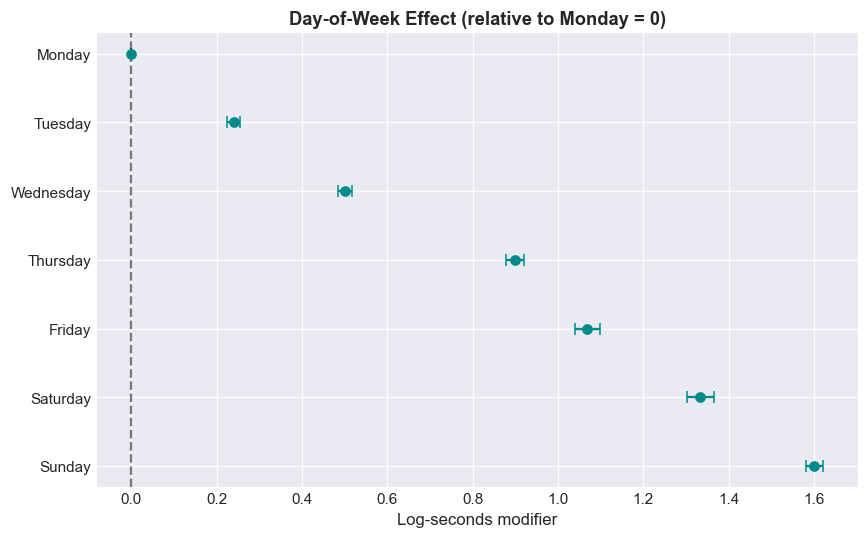

In [43]:
#@title Visualize OLS Model Findings - Day of Week
day_cols = list(day_dummies.columns)

day_coef = [0.0] + [ols_model.params[c] for c in day_cols]          # Monday = 0, matching the Bayesian baseline
day_ci_lo = [0.0] + [ols_model.conf_int().loc[c, 0] for c in day_cols]
day_ci_hi = [0.0] + [ols_model.conf_int().loc[c, 1] for c in day_cols]

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(7)
xerr = [np.array(day_coef) - np.array(day_ci_lo), np.array(day_ci_hi) - np.array(day_coef)]
ax.errorbar(day_coef, y_pos, xerr=xerr, fmt='o', color='darkcyan', capsize=4)
ax.set_yticks(y_pos)
ax.set_yticklabels(day_labels_full)
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.invert_yaxis()
ax.set_title("Day-of-Week Effect (relative to Monday = 0)")
ax.set_xlabel("Log-seconds modifier")
plt.tight_layout()
plt.show()

There is a very strong "day of week" signal in the data. New York Times goes through considerable editorial pains to ensure that difficulty is calibrated accurately for each day and we have enough days in the dataset to ride out any stochasticity. Accordingly, we get very tight error bars here.

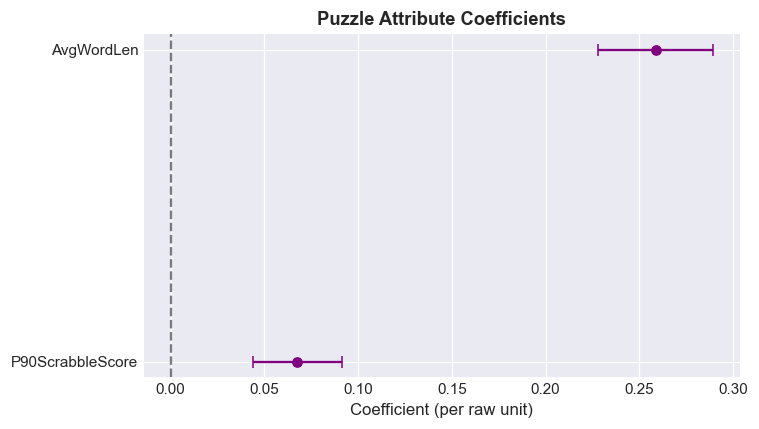

In [44]:
#@title Visualize OLS Model Findings - Puzzle Attributes
attr_coef = [ols_model.params[c] for c in continuous_features]
attr_ci_lo = [ols_model.conf_int().loc[c, 0] for c in continuous_features]
attr_ci_hi = [ols_model.conf_int().loc[c, 1] for c in continuous_features]

fig, ax = plt.subplots(figsize=(7, 4))
y_pos = np.arange(len(continuous_features))
xerr = [np.array(attr_coef) - np.array(attr_ci_lo), np.array(attr_ci_hi) - np.array(attr_coef)]
ax.errorbar(attr_coef, y_pos, xerr=xerr, fmt='o', color='purple', capsize=4)
ax.set_yticks(y_pos)
ax.set_yticklabels(continuous_features)
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.invert_yaxis()
ax.set_title("Puzzle Attribute Coefficients")
ax.set_xlabel("Coefficient (per raw unit)")
plt.tight_layout()
plt.show()


I was somewhat skeptical of these features since they are quite coarse (a puzzle might have a low AvgWordLen but with a couple of long answers that make it very difficult etc.) and they are correlated with day of week. I was pleasantly surprised to find that both effects are positive and with error bars away from $0$.  

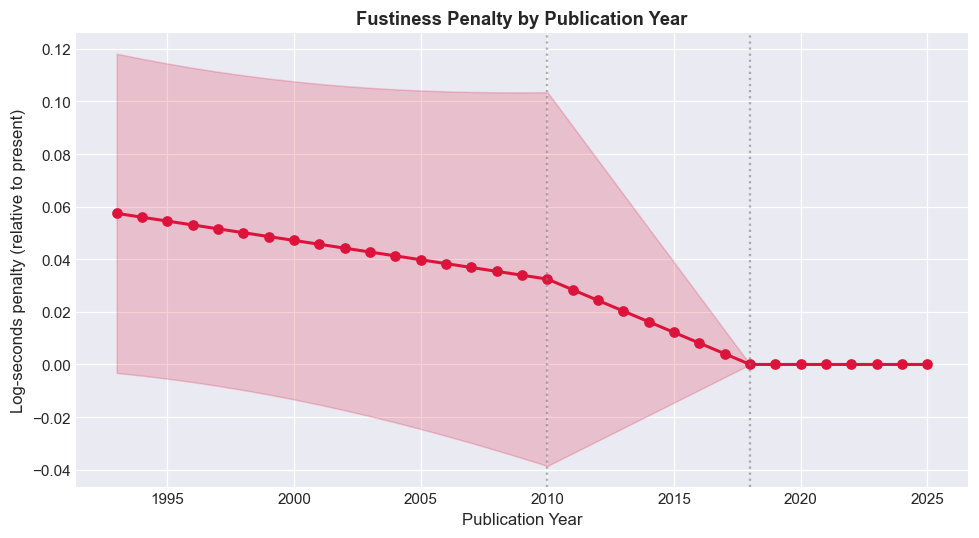

In [45]:
#@title Visualize OLS Model Findings - Puzzle Fustiness
year_grid = np.arange(df['PuzzleDate'].dt.year.min(), df['PuzzleDate'].dt.year.max() + 1)
fusty_grid = pd.DataFrame({
    'gap_since_recent_knot': np.maximum(0.0, FUSTY_KNOT_RECENT - year_grid.astype(float)),
    'gap_since_old_knot': np.maximum(0.0, FUSTY_KNOT_OLD - year_grid.astype(float)),
})

fusty_mean, fusty_se = linear_combo_with_se(
    ols_model, fusty_grid, ['gap_since_recent_knot', 'gap_since_old_knot']
)

plt.figure(figsize=(9, 5))
plt.plot(year_grid, fusty_mean, color="crimson", marker='o', lw=2)
plt.fill_between(year_grid, fusty_mean - 1.96 * fusty_se, fusty_mean + 1.96 * fusty_se,
                  color="crimson", alpha=0.2)
plt.axvline(FUSTY_KNOT_OLD, color='gray', linestyle=':', alpha=0.6)
plt.axvline(FUSTY_KNOT_RECENT, color='gray', linestyle=':', alpha=0.6)
plt.title("Fustiness Penalty by Publication Year")
plt.xlabel("Publication Year")
plt.ylabel("Log-seconds penalty (relative to present)")
plt.tight_layout()
plt.show()


Fustiness does not work at all. This is a weak effect at best with huge CI. Even the directionality of fustiness is quite fragile and goes the wrong way if model specifications change a bit (like changing the number of knots in the spline).

### Why is Fustiness difficult to measure?

It turns out there is a data-driven reason that makes puzzle fustiness difficult to measure. It has to do with the order in which I solved the archive puzzles.

There is a fundamental tension between fustiness and ability - they impact solving time in opposite ways (am I slow because the puzzle is fusty or because my ability is limited?). To truly disambiguate between them, we need data in all 4 buckets.

|  | Low Ability | High Ability |
| :--- | :---: | :---: |
| **Low fustiness** | Daily puzzles solved early <br> in the solving journey (2017-18) <br> <br> Relatively few puzzles in the data | Daily solves from 2022 onwards <br> when my ability has roughly plateaued <br> <br> Well represented in the data |
| **High fustiness** | Very old puzzles solved <br> early in the solving journey <br> <br> No such puzzles in the data | Puzzles solved towards the end <br> of the archival solve period (2021-22) <br> <br> Well represented in the data |

As we can see, we only have data in two regimes:
*   (high ability, low fustiness)  - daily solves from say 2023 onwards. Here, the two dimensions are working in tandem to reduce solve times - puzzles are smooth/topical _and_ my skill levels are high.
*   (high ability, high fustiness) - archive solves of pre-2000 puzzles in 2021-22. Here, the two dimensions are working in opposition - the puzzles are quite dated and might prove challenging despite my increased solving ability.

Ability and fustiness are not highly correlated in the data but it is the next worst thing. There are two regimes and the two variables are either highly correlated or perfectly anti-correlated in these two regimes. Given this structural issue, any modeling form is going to struggle to disambiguate their effects and we will see this play out across all model forms.


There are some ways to break out of this correlation trap that I will discuss towards the end. But now, let us move to a more sophisticated model form that allows us to bring more information into the modeling framework.

<a id="mixed"></a>
[&#8593; Back to top](#top)

## Mixed-effect Modeling

### Motivation

One crucial piece of information that we haven't used thus far in modelling is the constructor of the puzzle. If a constructor is known to be tough, solve times on their puzzles are likely to be longer than average. This feels like useful information to include in the model but there are some problems:
*   There are thousands of constructors in the data and it is impractical (and impossible) to model all of them using OLS (where each of them would be given a dummy variable)
*   Even if we were willing to do that, the quality of data will vary widely across constructors. Some constructors will have many puzzles which allows us to learn their "style". Most will have only one puzzle and that will tell us nothing.
*   There is a fundamental technical limitation beyond these sample size limitations - OLS assumes that all errors are uncorrelated, an assumption that will be violated with constructors in the model. If a constructor has $20$ puzzles and has a very difficult style compared to the average, the $20$ errors in those $20$ observations will all be higher than average - in other words, they would be correlated. OLS is not equipped to deal with this correlation which in turn will make the confidence intervals of OLS estimates overly optimistic. Roughly, this correlation structure brings down the effective sample size. We no longer have $N$ independent pieces of observations but OLS does not know this and will continue to use $N$ in the denominator for variance estimates of the type $\sigma^2/N$ (again, roughly) when it should be dividing by some $M < N$. This results in smaller errors when correlated data is estimated using OLS.

How can we bring this information into the model robustly?

### About Constructors

Across the $\approx$ 11,000 puzzles in the data, there are 2024 unique constructors. Many are published only once while some have hundreds of puzzles!!

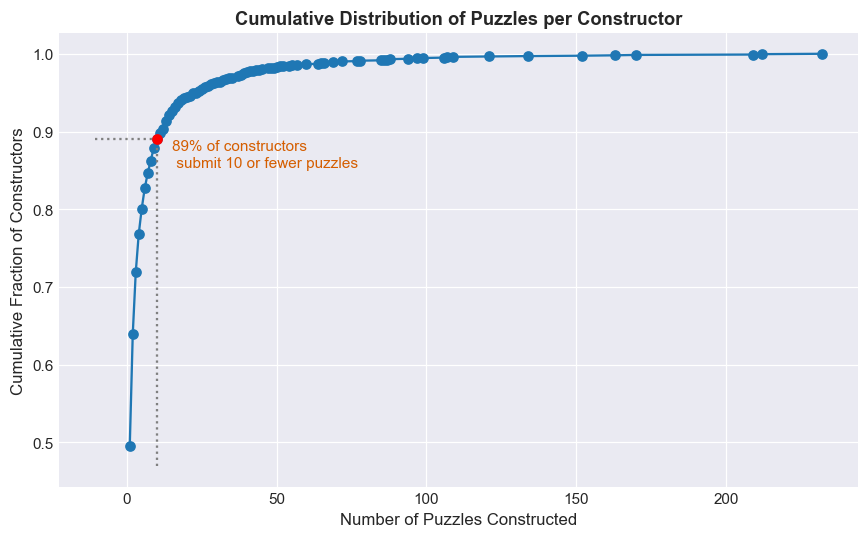

In [46]:
#@title Distribution of Constructors
# Count puzzles per constructor
constructor_puzzle_counts = df["Constructor"].value_counts().rename("N").reset_index()

# Count how many constructors have each puzzle count and sort
constructor_counts_summary = (
    constructor_puzzle_counts["N"]
    .value_counts(sort=False)
    .sort_index()
    .rename("Count")
    .reset_index()
)
constructor_counts_summary.columns = ['NumPuzzlesConstructed', 'Count']

# Calculate cumulative fraction of constructors
constructor_counts_summary["FracOfConstructors"] = constructor_counts_summary["Count"].cumsum() / constructor_counts_summary["Count"].sum()

x0_annotate = 10
y0_annotate = constructor_counts_summary[constructor_counts_summary['NumPuzzlesConstructed'] <= x0_annotate]['FracOfConstructors'].max()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(constructor_counts_summary["NumPuzzlesConstructed"], constructor_counts_summary["FracOfConstructors"], marker="o", linestyle="-")
ax.set_xlabel("Number of Puzzles Constructed")
ax.set_ylabel("Cumulative Fraction of Constructors")
ax.set_title("Cumulative Distribution of Puzzles per Constructor")

# Add annotation lines from the point to the axes
ax.plot([x0_annotate, x0_annotate], [ax.get_ylim()[0], y0_annotate], color='gray', linestyle=':', linewidth=1.5)
ax.plot([ax.get_xlim()[0], x0_annotate], [y0_annotate, y0_annotate], color='gray', linestyle=':', linewidth=1.5)

# Add annotation point and text
ax.scatter([x0_annotate], [y0_annotate], color='red', zorder=5)
ax.text(x0_annotate + 5, y0_annotate,
        f"{y0_annotate:.0%} of constructors\n submit {x0_annotate} or fewer puzzles",
        verticalalignment='top',
        color='#D55E00')

plt.tight_layout()
plt.show()

Some interesting observations from this data:

*   **Manny Nosowsky** leads the list of constructors with a whopping $232$ published puzzles followed by **Patrick Berry** ($212$) and **Elizabeth C. Gorski** ($209$). The actual numbers are even higher because sometimes they are credited with slightly different names (Patrick D. Berry for example).
*   Nearly $90\%$ of the $2024$ constructors have 10 or fewer puzzles to their credit. Around half of them have published just once. This is too little data for the model to learn anything about their construction styles and difficulty levels
*   All is not lost though. There are around $200$ constructors who have enough data for us to say something meaningful about their construction styles.

Given this distribution, we shouldn't expect a dramatically different model when information about constructors is brought in. Including this information in the model might not improve model fit but it _can_ provide rich insights about frequent publishers.

### Deriving the Mixed-effects model

The example of Constructors in this dataset is a great use-case for a mixed effects model. To see why, let us imagine a situation where that is the only variable available for modeling.

Let $y_{ij}$ be the solve time of the $j$-th puzzle by constructor $i$ where $i = 1,\dots, J$ are the distinct constructors and $j = 1, \dots, n_i$ are different puzzles by constructor $i$. Crucially, $n_i$ can vary wildly between $1$ (for $50\%$ of constructors in our data) and $100-200$.

#### **Global Model**

The trivial way to model this is as $$y_{ij} = \mu + \epsilon_{ij}$$ The estimate is simply $$\hat{\mu} = \frac{1}{N} \sum_{j=1}^{N} y_{ij}$$ where $N = \sum_i n_i$. This will be a robust estimate (since $N \approx 11,000$) but flattens out any variation across constructors.

#### **Fixed-Effects Model**

The "fixed-effects" (OLS) approach is to model this as $$y_{ij} = \alpha_i + \epsilon_{ij}$$
Every constructor gets their own coefficient $\alpha_i$ estimated on the basis of their puzzles. This estimate will simply be $$\hat{\alpha}_i = \frac{1}{n_i} \sum_{j=1}^{n_i} y_{ij} $$ 

This will be a robust estimate for constructors with $n_i > 50$ or so but will be a disaster for the $90\%$ of constructors with $n_i \leq 10$ where we will get widely fluctuating estimates.

#### **Mixed-Effects Model - Or Will Shortz is a Gaussian Enforcer**

The so-called Mixed effects or Random effects model strikes a midpoint between these two extremes. It posits that 
$$y_{ij} = \alpha_i + \epsilon_{ij} \qquad \alpha_i \sim \mathcal{N}(\mu,\tau^2)$$
or equivalently
$$y_{ij} = \mu + \left( \eta_i + \epsilon_{ij} \right) \qquad \eta_i \sim \mathcal{N}(0,\tau^2)$$

**Fixed-effects to Mixed-effects**: The first equation looks identical to the fixed-effects model except for the additional structural constraint on $\alpha_i$. Instead of estimating each constructor in isolation (like we would have done in a fixed-effects model), we are recognizing that they come from the same underlying distribution. This assumption makes a lot of sense in the real world. In this particular example, puzzles have a certain quality control imposed by the crossword editor and so are not going to be impossibly difficult or childishly easy for the most part. Put simply, Will Shortz is $\tau^2$. Every constructor is allowed to be unique (their skill is not a fixed constant but varies "randomly") but they all have to answer to Will Shortz whose editorial instincts will organically impose a Gaussian structure across constructors. He will want puzzles that are roughly similar in difficulty with the occasional very difficult (and very easy) constructors.

**Global model to Mixed-effects**: The second equation looks identical to the global model except for the additional structural constraint on $\epsilon_{ij}$ which is now being decomposed into $\eta_i + \epsilon_{ij}$. Instead of dumping all unexplained variation into a single, undifferentiated bucket of random noise ($\epsilon_{ij}$), we are recognizing that a puzzle's deviation from the global baseline isn't just an independent fluke; a portion of that deviation is a persistent "signature" ($\eta_i$) belonging to that specific constructor, while the remainder ($\epsilon_{ij}$) is the puzzle-specific randomness. Will Shortz is again the enforcer of the limits of this signature in the same way as above.

The name "random effects" comes from this interpretation of $\alpha_i \sim N(\mu, \tau^2)$ and we often see language like "coefficients are drawn from a distribution". But I find that the best way to internalize this is to not think of the word "random" at all (which inevitably makes me think that the coefficients themselves are random) but rather think of random effects models as being identical to fixed effects models with some additional "domain knowledge" that constrains the range of their possible values.

#### **Deriving the Mixed-Effects Model**

We can sketch out a rough proof of the mixed-effects estimator as follows. Assume that the estimate takes the form $$ \hat{\alpha}_i = w_i \bar{y}_i + (1-w_i) \mu$$ where we are trying to find an optimal $0 \leq w_i \leq 1$. It takes a bit more work to establish that the optimal linear estimate _must_ take this form but the equation is intuitive enough.

We know that $$\bar{y}_i = \alpha_i + \bar{\epsilon}_i$$ where $Var(\bar{\epsilon}_i) = \frac{\sigma^2}{n_i}$

Error estimate is $$\bar{\alpha}_i - \alpha_i = w_i \bar{y}_i + (1-w_i) \mu - \alpha_i \\ = w_i ( \alpha_i + \bar{\epsilon}_i )+ (1-w_i) \mu \\ = (w_i-1)(\alpha_i - \mu) + w_i \bar{\epsilon}_i \\ = (w_i-1) \tau_i + w_i \bar{\epsilon}_i$$

$\tau_i$ is how far constructor $i$ is from the global average constructor and $\bar{\epsilon}_i$ is how much inter-puzzle variation that constructor has. These are two different processes and therefore are uncorrelated. This means that the MSE is simply $$ E[(\bar{\alpha}_i - \alpha_i)^2] = (w_i-1)^2 \tau^2 + w_i^2 \frac{\sigma^2}{n_i}$$

Finding $w_i$ to minimize this is a simple calculus exercise and will give us $$w_i = \frac{\tau^2}{\tau^2 + \sigma_i^2/n_i}$$ Putting it all together, we get $$ \hat{\alpha}_i = \left( \frac{\tau^2}{\tau^2 + \sigma_i^2/n_i} \cdot \bar{y}_i \right)+ \left( \frac{\sigma_i^2/n_i}{\tau^2 + \sigma_i^2/n_i} \cdot \mu \right)$$

This is pooling at work. We can see how this estimate makes physical sense in all scenarios.
*   If $n_i$ is small, $w_i \rightarrow 0$ and $\hat{\alpha}_i \rightarrow \mu$. If a constructor has few puzzles, the model will shrink their estimates to the global mean.
*   If $\tau^2$ is small, Will Shortz is being very strict and is expecting every constructor to be close to the global mean _on average_. Since $\hat{\alpha}_i$ estimates only this mean, we might as well let $\hat{\alpha}_i \rightarrow \mu$. The analogy is a little strained here - crossword editors will not look at aggregate difficulty of a constructor across puzzles but this is effectively what the data model is telling us.
*   If $n_i$ is very large, $w_i \rightarrow 1$: there is enough data to overcome the structural constraint, so $\hat{\alpha}_i \rightarrow \bar{y}_i$. Once a constructor has enough puzzles to speak for themselves, the constraint stops mattering.
*   If $\sigma_i^2 \rightarrow 0$, there is no noise to worry about. Even if we see 1 puzzle from a constructor, that _is_ the right estimate for that constructor and we should let $\hat{\alpha}_i \rightarrow \bar{y}_i$


### Implementing a mixed effects model

Implementation is a one-line change from the OLS fit. We keep exactly the same fixed-effect design matrix $X$ (splines, day dummies, fustiness hinge, attributes, archive flag) and hand `statsmodels` a `groups` argument for the constructor:

```python
sm.MixedLM(log_solve_time, X, groups=df['Constructor']).fit(reml=True)
```

This adds a single random intercept per constructor, $\alpha_i \sim N(0, \tau^2)$, on top of the shared fixed effects. 

*   To reiterate, Mixed effects is same as doing OLS (which will assign a different intercept for each constructor) with an added constraint that all of them come from the same distribution $N(\mu, \tau^2)$
*   This $\mu$ will get absorbed into the intercept leaving only $\alpha_i \sim N(0, \tau^2)$ which can be thought of as the deviation of constructor $i$ from the global average constructor.
*   In the langauge of optimiation and objective functions, the line above adds a penalty $\alpha_i$ for every constructor (positive penalty => tougher constructor) and stipulates that this penalty cannot be too extreme (variance has to be $\tau^2$)



**What is REML?** By default we fit with **Restricted (or Residual) Maximum Likelihood** rather than ordinary ML. The problem with plain ML is that it estimates the fixed effects $\beta$ and the variance components $(\tau^2, \sigma^2)$ jointly, and in doing so it systematically *underestimates* the variances — it doesn't account for the degrees of freedom "spent" nailing down the fixed effects. It's the same reason we divide by $n-1$ rather than $n$ for a sample variance. REML sidesteps this by estimating the variance components from the residuals left *after* projecting out the fixed effects, giving much less biased estimates of $\tau^2$ and $\sigma^2$. Given that we have far more observations than parameters, the difference between REML (which will give unbiased estimates) and ML (which will maximize likelihood but will be biased slightly) will be negligible.

In [47]:
#@title Adding a random effect term for Constructor

# Suppress convergence warnings - reasons for this warning are discussed below
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning) # Suppress only the ConvergenceWarning from statsmodels


mixed_model = sm.MixedLM(log_solve_time, X, groups=df['Constructor'])
fit_result = mixed_model.fit(reml=True)
print(fit_result.summary())

constructor_var = fit_result.cov_re.iloc[0, 0]
residual_var = fit_result.scale
print(f"\nConstructor variance component: {constructor_var:.5f}  (sigma_constructor analog: {np.sqrt(constructor_var):.4f})")
print(f"Residual variance: {residual_var:.5f}  (sigma analog: {np.sqrt(residual_var):.4f})")


              Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    y         
No. Observations:    11661      Method:                REML      
No. Groups:          2024       Scale:                 0.0863    
Min. group size:     1          Log-Likelihood:        -2514.5050
Max. group size:     232        Converged:             No        
Mean group size:     5.8                                         
-----------------------------------------------------------------
                      Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
const                  4.413    0.085  52.020 0.000  4.247  4.580
ability_spline_0      -0.291    0.034  -8.658 0.000 -0.357 -0.225
ability_spline_1      -0.585    0.030 -19.544 0.000 -0.644 -0.526
ability_spline_2      -0.749    0.028 -27.221 0.000 -0.802 -0.695
ability_spline_3      -0.934    0.029 -31.796 0.000 -0.991 -0.876
ability_spline_4      -0

### Insights from the mixed-effects model

You can compare the two models side-by-side and see that there is very little difference in the coefficients.

|  | OLS | Mixed Effects |
| :--- | :---: | :---: |
| **const** | 4.4051 | 4.413 |
| **ability_spline_0** | -0.286 | -0.291 |
| **ability_spline_1** | -0.5848 | -0.585 |
| **ability_spline_2** | -0.7533 | -0.749 |
| **ability_spline_3** | -0.9449 | -0.934 |
| **ability_spline_4** | -0.9064 | -0.907 |
| **ability_spline_5** | -0.953 | -0.948 |
| **ability_spline_6** | -1.0103 | -1.012 |
| **day_Tuesday** | 0.2398 | 0.241 |
| **day_Wednesday** | 0.5007 | 0.5 |
| **day_Thursday** | 0.8988 | 0.893 |
| **day_Friday** | 1.0685 | 1.066 |
| **day_Saturday** | 1.3331 | 1.305 |
| **day_Sunday** | 1.6011 | 1.599 |
| **gap_since_recent_knot** | 0.0041 | 0.002 |
| **gap_since_old_knot** | -0.0026 | -0.001 |
| **AvgWordLen** | 0.2588 | 0.26 |
| **P90ScrabbleScore** | 0.0675 | 0.062 |
| **is_archive_solve** | 0.1699 | 0.172 |
| **sigma_constructor** |  | 0.0652 |

This is to be expected since the new data source that we have added (Puzzle Constructor) is not rich enough to significantly move the needle. To be sure, constructors do play a big part in solve times but with nearly $90\%$ of the constructors having less than $10$ puzzles, there isn't a strong signal to estimate. Note that the only coefficients that move significantly are the fustiness coefficients which are very fragile to begin with.

### Plotting ability

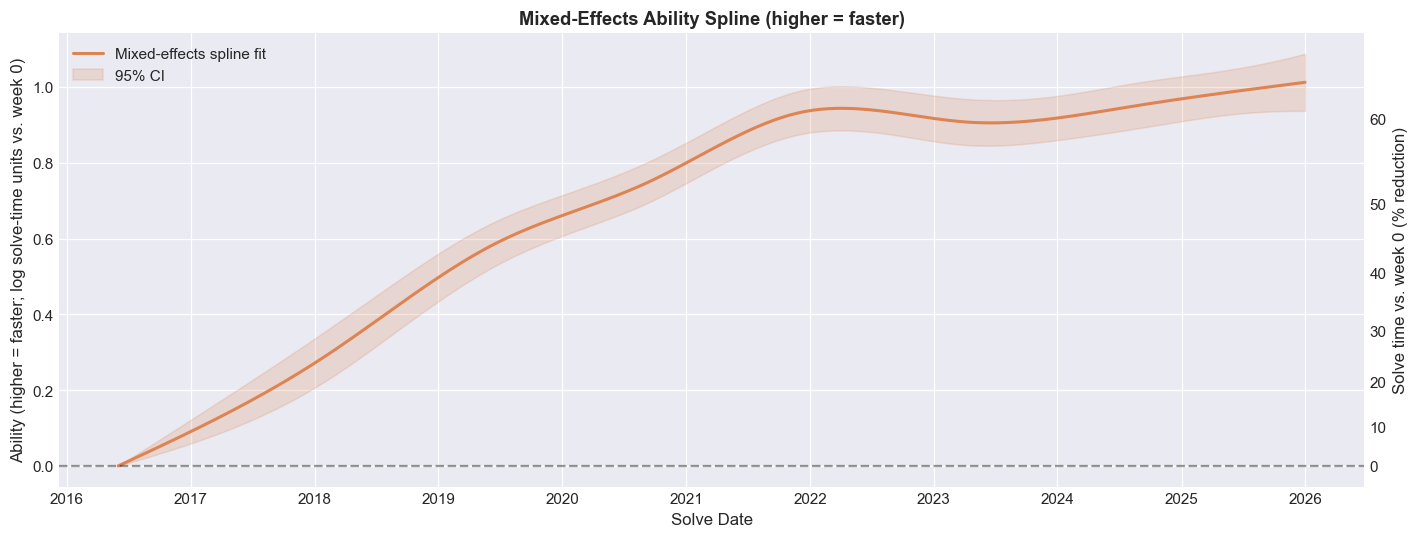

(<Figure size 1430x550 with 1 Axes>,
 <Axes: title={'center': 'Mixed-Effects Ability Spline (higher = faster)'}, xlabel='Solve Date', ylabel='Ability (higher = faster; log solve-time units vs. week 0)'>)

In [48]:
#@title Visualize Mixed-Effects Model Findings - Ability

# Reuses t_grid / date_grid / _ability_grid_basis and the helpers defined in the
# OLS ability cell above -- no need to rebuild the spline grid.
ability_mean_MixEff, ability_se_MixEff = ability_from_splines(fit_result)
plot_ability_curve(
    date_grid, ability_mean_MixEff,
    ability_mean_MixEff - 1.96 * ability_se_MixEff,
    ability_mean_MixEff + 1.96 * ability_se_MixEff,
    "Mixed-Effects Ability Spline (higher = faster)", "Mixed-effects spline fit",
    PALETTE['mixed'],
)


The fit is largely the same and so the ability curve is largely the same. Just as we did with the OLS, we can back into a confidence interval for this ability as well. The underlying math to compute the covariance of the coefficients is more complicated than in the OLS case but it is conceptually similar. However, it is important to note that there is no notion here of the skill trajectory being a *random quantity* with its own distribution. It's a fixed function of fixed coefficients, and the band treats those coefficients as the only source of uncertainty — it ignores, for instance, our uncertainty about the variance components. It works, but it's patched up rather than intrinsic and organic.

### Estimating $\tau^2$

The one new coefficient above is Group Var which is the estimated value of $\tau^2 = 0.00425$. Recall that this is the variance of the distribution of the deviation of a given constructor from the global mean.

To get a sense of the magnitude of this quantity, note that the residual variance $\sigma^2 = 0.08632$ which means that the constructor component explains $$\frac{\tau^2}{\tau^2 + \sigma^2} = \frac{0.00425}{0.00425 + 0.08632} = 4.69\%$$ of the variance. This again makes sense - we won't expect this variable to explain a big chunk of the variance in the system.

### Why does the model struggle to converge

Also, remember that within any one group (constructor), the two competing sources of noise are $\tau^2$ and $\frac{\sigma^2}{n_i}$ - for them to be comparable, we need $n_i \approx \frac{\sigma^2}{\tau^2} = \frac{0.08632}{0.00425} = 20.3$.

Only around $5\%$ of the constructors qualify for this cutoff. Everyone else gets shrunk to $0$ and the model has the unenviable task of estimating $\tau^2$ based only on these $100$ odd constructors.

With so little data, it is possible that there isn't a strong signal to pin down the exact value of $\tau^2$. In other words, multiple values of $\tau^2$ can give similar overall loss. This causes convergence errors and other weird behavior depending on the optimizer used.

### Shrinkage in Mixed Effects Models

We can see shrinkage in action in the estimation of "random" intercepts for constructors.

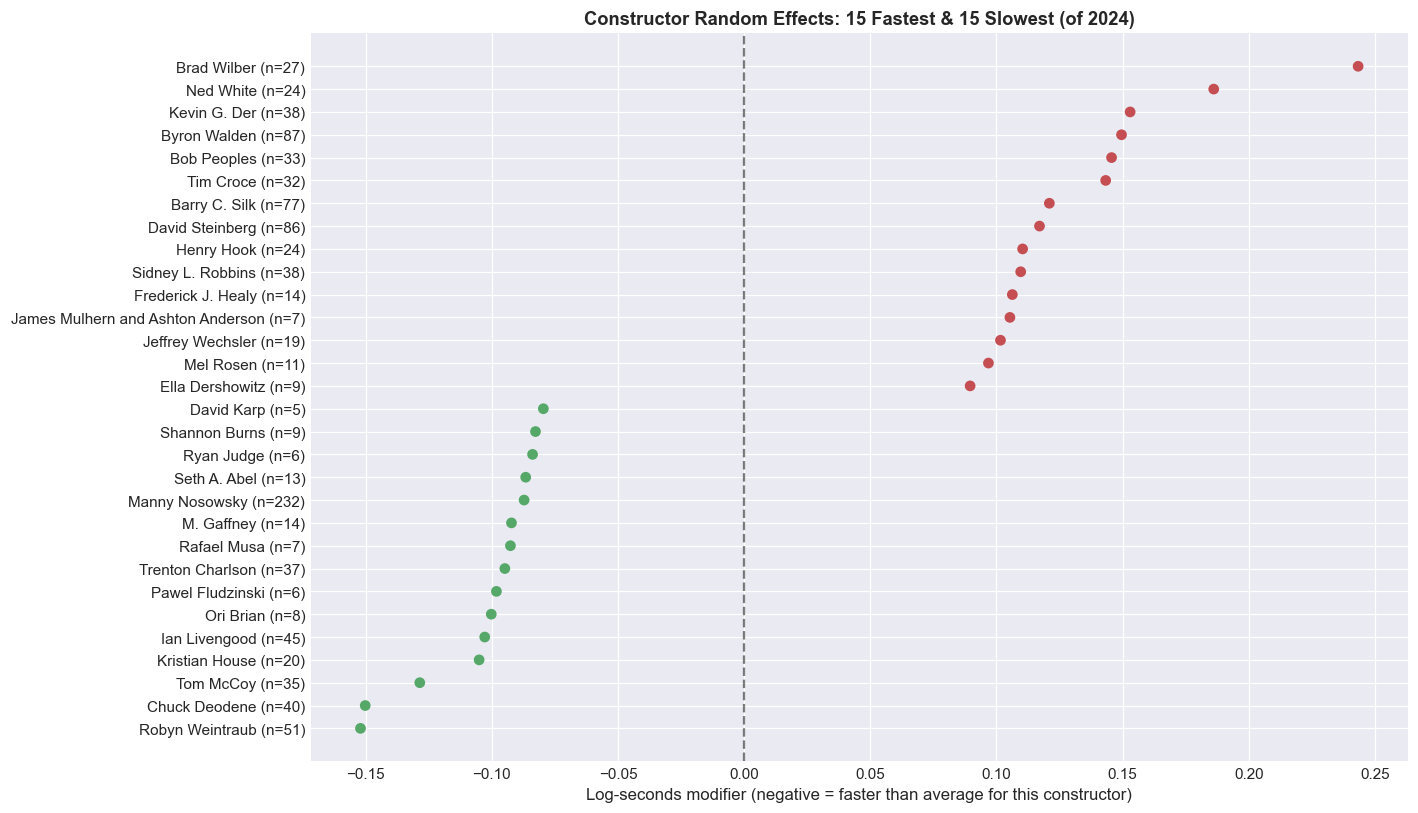

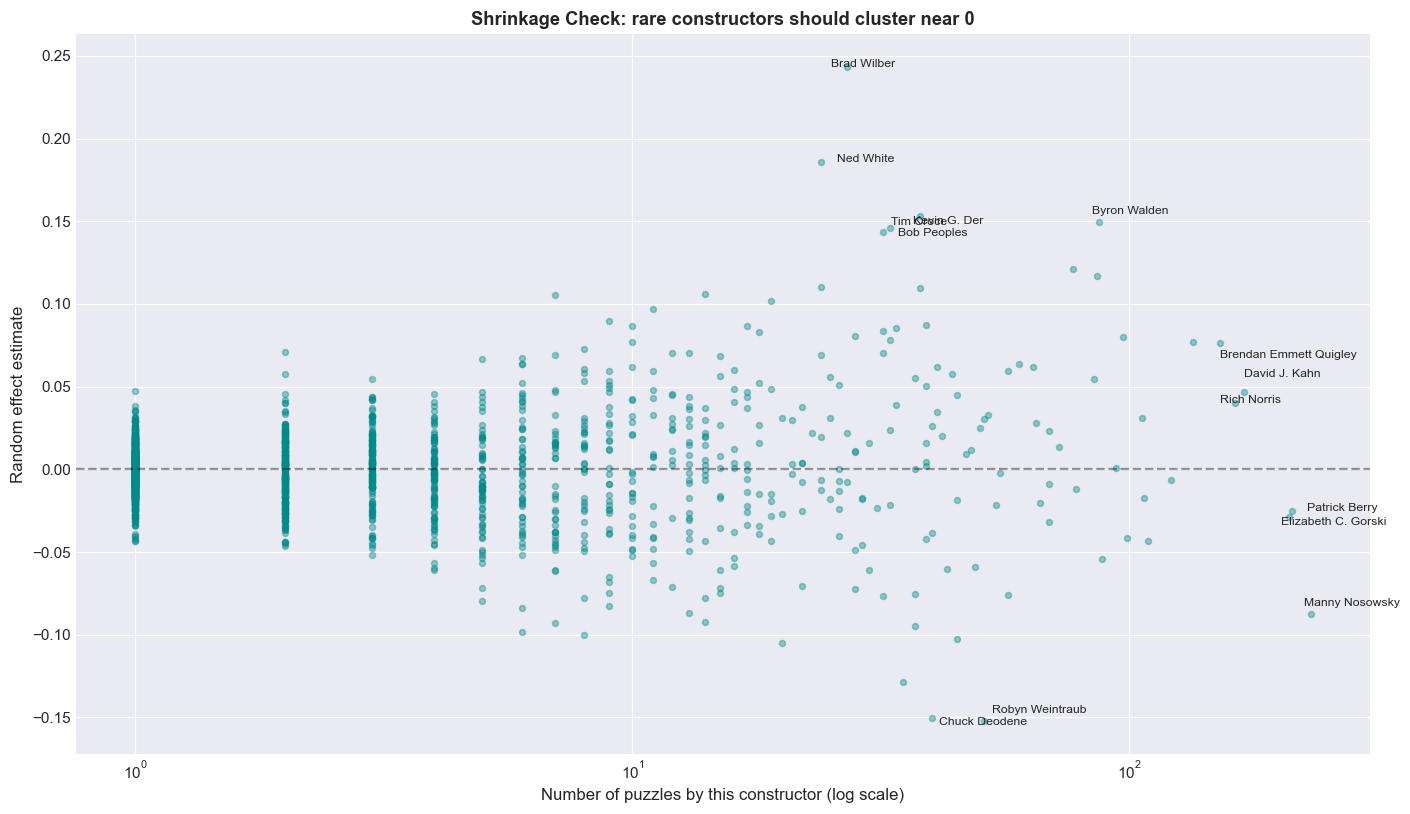

In [49]:
#@title Intercepts for Constructors
try:
    random_effects = fit_result.random_effects
except Exception as e:
    random_effects = None
    print(f"Could not extract random effects (often means the constructor variance component "
          f"collapsed to ~0, i.e. no detectable cross-constructor differences): {e}")

if random_effects is not None:
    constructor_means = {k: v.iloc[0] for k, v in random_effects.items()}
    n_puzzles_per_constructor = df['Constructor'].value_counts()

    constructor_df = pd.DataFrame({
        'constructor': list(constructor_means.keys()),
        'mean_effect': list(constructor_means.values()),
    })
    constructor_df['n_puzzles'] = constructor_df['constructor'].map(n_puzzles_per_constructor)
    constructor_df = constructor_df.sort_values('mean_effect')

    N_SHOW = 15
    extremes = pd.concat([constructor_df.head(N_SHOW), constructor_df.tail(N_SHOW)])

    fig, ax = plt.subplots(figsize=(13, 7.5))
    y_pos = np.arange(len(extremes))
    point_colors = [PALETTE['neg'] if v < 0 else PALETTE['pos'] for v in extremes['mean_effect']]
    ax.scatter(extremes['mean_effect'], y_pos, color=point_colors, zorder=5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f"{row.constructor} (n={int(row.n_puzzles)})" for row in extremes.itertuples()])
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f"Constructor Random Effects: {N_SHOW} Fastest & {N_SHOW} Slowest (of {len(constructor_df)})")
    ax.set_xlabel("Log-seconds modifier (negative = faster than average for this constructor)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(13, 7.5))
    plt.scatter(constructor_df['n_puzzles'].clip(lower=1), constructor_df['mean_effect'],
                alpha=0.4, color='darkcyan', s=15)
    plt.xscale('log')
    plt.axhline(0, color='black', linestyle='--', alpha=0.4)
    plt.xlabel("Number of puzzles by this constructor (log scale)")
    plt.ylabel("Random effect estimate")
    plt.title("Shrinkage Check: rare constructors should cluster near 0")

    xy_offsets = itertools.cycle([(5, 5), (5, -5), (-5, 5), (-5, -5), (10, 0), (-10, 0), (0, 10), (0, -10)])
    for i, row in constructor_df.iterrows():
        if abs(row['mean_effect']) > 0.14 or row['n_puzzles'] > 150:
            offset = next(xy_offsets)
            plt.annotate(row['constructor'], (row['n_puzzles'], row['mean_effect']),
                         textcoords="offset points", xytext=offset, ha='left', fontsize=8)
    plt.tight_layout()
    plt.show()


Constructors with fewer puzzles are given intercepts close to $0$ and we see some disperson away from the origin as we move to the right. But we cannot easily put error bars or confidence intervals around these points. For instance, our model thinks David Karp is among the 15 easiest constructors but how confident can we be of that fact with just $n = 5$ puzzles? We genuinely can't tell whether a low-sample constructor's ranking reflects a real style effect or just a couple of lucky/unlucky solves. The mixed-effects framework hands us point estimates; the per-constructor uncertainty *can* be extracted from the model but it is awkward and does not include all sources of uncertainty.

### Reverend Bayes to the Rescue

A big problem with this model specification is that the difficulty in estimating $\tau^2$ (which caused the convergence issues we discussed above) is not organically propagated downstream. For example, in this analysis of the relative ranking of constructors, we treated $\tau^2 = 0.00425$ as gospel truth despite the fact that, as we just saw, the model was creaking and groaning to estimate it.

Bayesian regression offers an alternative to this. We put a weakly informative ("wide") prior on $\tau$ and let the model estimate a posterior based on the data. If the data is inconclusive (as in this case), the posterior $p(\tau \mid \text{data})$ will be wide as well. Crucially, all downstream processing will use this posterior distribution and so be fully aware of this uncertainty in $\tau^2$. For example, constructor ranks will be derived by averaging the computation across all values of $\tau^2$ drawn from the posterior and so will be sensibly spread out themselves (instead of committing to a point estimate).

<a id="bayesian"></a>
[&#8593; Back to top](#top)

## Bayesian models

Bayesian statistics gives us a clean way to handle these uncertainties in the data. A fully Bayesian model places uncertainty front and center. Every quantity in the system ( each constructor's intercept, each week's ability, fustiness, ...) gets a full posterior, so credible intervals fall out automatically and propagate through everything downstream; no scaffolding is needed to extract these errors. We can look at David Karp's posterior (an unfortunate choice of words!!) and ask whether their intercept is distinguishable from zero.

**And it buys us more.** Rather than estimating ability using arbitrarily specified splines, we can model it as a **first-order random walk**: a flexible, nearly-nonparametric trajectory whose smoothness is controlled by a single innovation-variance prior. The data dictates the *shape* of the skill curve, and the uncertainty naturally widens wherever data is thin, neither of which the fixed spline gives us cleanly.

### Establishing a connection with mixed effects

Let us go back to the model regressing solve times against just constructors. This time, we can use the Bayesian language to describe the same system. In the Bayesian world, the intercepts across constructors are described by a global prior, $\alpha_i \sim N(\mu,\tau^2)$. For constructor $i$ with a difficulty level of $\alpha_i$ and $n_i$ published puzzles, we model the solve times as $y_{ij} \sim N(\alpha_i, \sigma^2)$. For simplicity, let us assume that we know the variances $\sigma^2$ and $\tau^2$. We can then try to estimate the posterior of $\alpha_i$ given the observations, i.e., $p(\alpha_i \mid y_{ij}, j = 1, 2, \dots, n_i)$

It is intuitive that the posterior will only depend on the group mean $\bar{y}_i = \frac{1}{n_i} \sum_{j=1}^{n_i} y_{ij}$, whose sampling distribution given the constructor's true level is $\bar{y}_i \mid \alpha_i \sim N\!\left(\alpha_i, \tfrac{\sigma^2}{n_i}\right)$. So, the problem reduces to the following: 

Given that
$$ \begin{aligned} \alpha_i &\sim N(\mu, \tau^2) \qquad (\text{prior}) \\
\bar{y}_i \mid \alpha_i &\sim N \left(\alpha_i, \frac{\sigma^2}{n_i} \right) \quad (\text{likelihood})
\end{aligned}
$$ 
estimate the posterior $\alpha_i \mid \bar{y}_i$

This is a classic normal-normal conjugate model and it is well known that the posterior will also be a normal under these conditions. The posterior is proportional to 
$$ \begin{aligned} 
P(\alpha_i \mid \bar{y}_i) &\propto p(\alpha_i) p(\bar{y}_i \mid \alpha_i) \\
&\propto \exp \left[ -\frac{1}{2} \left( \frac{(\bar{y}_i - \alpha_i)^2}{\sigma^2/n_i} + \frac{(\alpha_i - \mu)^2}{\tau^2} \right) \right]
\end{aligned} $$

The quadratic in $\alpha_i$ in the exponent can be written as $A \alpha_i^2 - 2 B \alpha_i + C$ where the $A$ and $B$ are given by
$$
\begin{aligned}
A &= \frac{n_i}{\sigma^2} + \frac{1}{\tau^2} \\
B &= \frac{n_i \bar{y}_i}{\sigma^2} + \frac{\mu}{\tau^2} \\
\end{aligned}$$
$C$ is a constant that doesn't matter (it will be absorbed in the proportionality constant). Simplifying this further, we get

$$
\begin{aligned}
P(\alpha_i \mid \bar{y}_i) &\propto \exp \left[ -\frac{1}{2} \left( A \alpha_i^2 - 2B\alpha_i + C\right) \right] \\
&\propto \exp \left[ -\frac{1}{2} A \left[ \left( \alpha_i - \frac{B}{A} \right)^2 - \left( \frac{B}{A} \right)^2 \right] \right] \\
&\propto \exp \left[ -\frac{1}{2} A \left( \alpha_i - \frac{B}{A} \right)^2 \right]
\end{aligned}
$$

This is the same form of a Gaussian pdf and so the posterior must be a Gaussian (if it is proportional to a Gaussian and it is also a valid pdf, the proportionality constant must be $1$). The posterior mean and variance can be read off from this functional form as $\frac{B}{A}$ and $\frac{1}{A}$ respectively.

Putting this all together, we get
$$
\begin{aligned}
\alpha_i \mid \bar{y}_i \sim N \left( \frac{\tau^2}{\tau^2 + \sigma^2/n_i} \bar{y}_i + \frac{\sigma^2/n_i}{\tau^2 + \sigma^2/n_i} \mu ,  \left( \frac{1}{\tau^2} + \frac{1}{\sigma^2/n_i}\right)^{-1} \right)
\end{aligned}
$$

This is exactly the shrinkage estimator we derived earlier through least-squares minimization. Take the constructor-only model with likelihood $\bar{y}_i \mid \alpha_i \sim N(\alpha_i,\, \sigma^2/n_i)$ and prior $\alpha_i \sim N(\mu, \tau^2)$. The posterior mean of $\alpha_i$ is

$$\mathbb{E}[\alpha_i \mid \bar{y}_i] = \underbrace{\frac{\tau^2}{\tau^2 + \sigma^2/n_i}}_{w_i}\,\bar{y}_i + \left(1 - w_i\right)\mu$$

which is *exactly* the mixed-effects estimator. In other words, the "domain-knowledge constraint" $\alpha_i \sim N(\mu, \tau^2)$ can be thought of as a Bayesian prior, and partial pooling is identical to Bayesian posterior shrinkage. What we called the mixed-effects fit is really *empirical Bayes*. 

So, how is Bayesian different from mixed-effects then?
 
### Bayesian is an organic evolution of mixed-effects modeling

Going fully Bayesian removes the "plug-in" step. Instead of fixing $\tau^2$ and $\sigma^2$ at their estimates, we put priors on them too and integrate over their uncertainty. *And* the uncertainities in these posterior distributions will percolate throughout the estimation process and inform all other estimates/derived quantities. We sample from the whole joint posterior and so every quantity in the system arrives with honest, self-consistent uncertainty rather than a lone point estimate.

### Motivating ability as a random walk

Rather than assume a parameteric form (linear, spline, logistic or any other form) for ability, we will model ability as a **first-order random walk**: $\text{ability}_k = \text{ability}_{k-1} + \sigma_{\text{skill}}\, z_k$. This says only that *skill changes gradually*. Next week's ability is this week's plus a small random nudge. The data decides the shape, and the uncertainty widens automatically wherever solves are sparse. You can see this in action below when we derive ability through Bayesian methods - the confidence intervals on ability widen a bit after $2022$ when the archival solves end and we are back to 1 puzzle per day.

Could we have done this in the OLS / mixed-effects world? Yes, and the connection is illuminating. A random-walk prior on adjacent coefficients is *exactly* a **penalized (P-)spline / smoothing spline** with a penalty on first differences. Minimizing

$$ \sum_i (\log t_i - \mu_i)^2 \;+\; \lambda \sum_k (\text{ability}_k - \text{ability}_{k-1})^2 $$

is the frequentist twin of our random walk, with $\lambda \propto \sigma^2 / \sigma_{\text{skill}}^2$ (choosing $\lambda$ to be exactly equal to this ratio is equivalent to normalizing both the terms to unit variance and adding them together. The proportionality constant then gives the relative weight of the 2nd penalty term compared to the first error term). A stiff walk (small $\sigma_{\text{skill}}$) corresponds to heavy smoothing (large $\lambda$). So the machinery exists in both worlds but choosing $\lambda$ the frequentist way means cross-validation and then treating the winning $\lambda$ as fixed and known. That is the same plug-in problem we hit with $\tau^2$. The Bayesian version instead puts a prior on $\sigma_{\text{skill}}$ and integrates over it, so the ability band honestly reflects our uncertainty about *how fast skill can move* rather than betting everything on one smoothing level.

In [50]:
#@title Label Encoders

class ClippingLabelEncoder(LabelEncoder):
    """
    A LabelEncoder whose .transform_with_clipping() never raises on an unseen label -- it maps unseen labels to the index of the LAST
    (largest) known class instead. Use this for SolveWeek/PublishYear.

    For Constructor, use the inherited plain .transform() instead: resolves are always a subset of historic puzzles, so an unseen constructor
    indicates a real data problem and SHOULD raise, not be clipped away.
    """
    def transform_with_clipping(self, values):
        values = np.asarray(values)
        known_mask = np.isin(values, self.classes_)
        max_idx = len(self.classes_) - 1
        out = np.full(len(values), max_idx, dtype=int)
        if known_mask.any():
            out[known_mask] = super().transform(values[known_mask])
        n_clipped = (~known_mask).sum()
        if n_clipped > 0:
            print(f"  (clipped {n_clipped} value(s) beyond the historic range to index {max_idx})")
        return out


# --- Fit encoders on the historic data only ---
year_encoder = ClippingLabelEncoder().fit(sorted(df['PuzzleDate'].dt.year.unique()))
week_encoder = ClippingLabelEncoder().fit(sorted(df['SolveDate'].dt.to_period('W').unique()))
constructor_encoder = ClippingLabelEncoder().fit(sorted(df['Constructor'].unique()))

num_years = len(year_encoder.classes_)
num_solve_weeks = len(week_encoder.classes_)
num_constructors = len(constructor_encoder.classes_)
unique_years = year_encoder.classes_
unique_solve_weeks = week_encoder.classes_
unique_constructors_list = list(constructor_encoder.classes_)

# --- Apply to historic data (plain .transform -- every category here is, by definition, one the encoder was just fit on) ---
publish_year_idx = year_encoder.transform(df['PuzzleDate'].dt.year.values)
solve_week_idx   = week_encoder.transform(df['SolveDate'].dt.to_period('W').values)
constructor_idx  = constructor_encoder.transform(df['Constructor'].values)
day_of_week_idx  = df['PuzzleDay'].map(day_mapping).astype(int).values

# --- Standardize continuous attributes (fit on historic, reused for resolves) ---
X_raw = df[continuous_features].values
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X_scaled = (X_raw - X_mean) / X_std
num_features = X_scaled.shape[1]

# log_solve_time was already computed in the feature-engineering cell above

n_rows = len(df)
print(f"Encoders fit. Years: {num_years} | Solve weeks: {num_solve_weeks} | Constructors: {num_constructors}")

Encoders fit. Years: 33 | Solve weeks: 498 | Constructors: 2024


### Specifying the Bayesian model

**Indices and data.** Index solved puzzles by $i = 1, \dots, N$ (here $N = 11{,}661$). Each puzzle carries a solve week $w(i) \in \{1,\dots,W\}$ ($W = 498$), a day of week $d(i) \in \{0,\dots,6\}$ (Monday $=0$), a publication year $y(i)$, a constructor $c(i) \in \{1,\dots,C\}$ ($C = 2{,}024$), an archive-solve flag $a_i \in \{0,1\}$, and two standardized grid attributes $x_{i1}, x_{i2}$ (AvgWordLen and P90ScrabbleScore, each z-scored). The response is $\log t_i$, the log of the solve time in seconds. Write $\mathcal{N}^{+}(0, s^2)$ for the half-normal (a $\mathcal N(0,s^2)$ folded to the non-negative axis) with scale $s$.

**Regression equation (the mean of the likelihood).**

For a puzzle $i$ published on the day of week $d(i)$ (Monday, Tuesday etc.), in the year $y(i)$ (fustiness depends on this), during week $w(i)$ of my solving journey (my skill level depends on this), by constructor $c(i)$, the solve time $t_i$ is modeled as 
$$
\log t_i \;\sim\; \mathcal{N}\!\left(\mu_i,\; \sigma^2\right), \qquad i = 1,\dots,N.
$$
where

$$
\mu_i \;=\; \underbrace{\alpha}_{\substack{\text{global} \\ \text{intercept}}}
\;\underbrace{-\;\text{ability}_{w(i)}}_{\substack{\text{my ability} \\ \text{in week $w(i)$}}}
\;\underbrace{+\;\text{day}_{d(i)}}_{\substack{\text{day of week} \\ \text{difficulty}}}
\;\underbrace{+\;\beta_{\text{arch}}\,a_i}_{\substack{\text{archive difficulty} \\ \text{intercept}}}
\;\underbrace{+\;\text{fust}_{y(i)}}_{\substack{\text{fustiness} \\ \text{in year $y(i)$}}}
\;\underbrace{+\;\sum_k \beta_k\, x_{ik}}_{\substack{\text{puzzle} \\ \text{difficulty}}}
\;\underbrace{+\;\gamma_{c(i)}}_{\substack{\text{difficulty of} \\ \text{constructor $c(i)$}}}
$$

Ability enters with a minus sign. It is the one term that *reduces* time while day difficulty, the archive-sweep shift, and fustiness push it up; attributes and the constructor effect can go either way. Because everything is additive in log-space, on the natural scale it's **multiplicative**:

**Global level and noise.**

$$
\alpha \sim \mathcal{N}(5.5,\, 1.0^2), \qquad \sigma \sim \mathcal{N}^{+}(0,\, 1.0^2).
$$

The prior mean $\alpha = 5.5$ encodes an $e^{5.5}\approx 4$-minute baseline; $\sigma$ is the irreducible per-solve noise.

**Latent skill — a first-order random walk (non-centered).**

$$
\sigma_{\text{skill}} \sim \mathcal{N}^{+}(0,\, 0.05^2), \qquad z^{\text{skill}}_j \sim \mathcal{N}(0,1), \quad j = 1,\dots,W-1,
$$

$$
\text{ability}_1 = 0, \qquad
\text{ability}_k = \text{ability}_{k-1} + \sigma_{\text{skill}}\, z^{\text{skill}}_{k-1}
\quad (k = 2,\dots,W)
$$

which unrolls to the innovation process

$$
\text{ability}_k = \sigma_{\text{skill}} \sum_{j=1}^{k-1} z^{\text{skill}}_{j}.
$$

Week 1 is pinned to $0$ as the reference; $\sigma_{\text{skill}}$ controls how far skill may drift week to week, and hence the smoothness of the trajectory. The increments are sampled as unit normals and scaled by $\sigma_{\text{skill}}$ (the non-centered form) rather than drawn directly.

**Day-of-week effect** (Monday fixed at $0$).

$$
\text{day}_m \sim \mathcal{N}(0,\, 1.5^2), \quad m = 1,\dots,6, \qquad \text{day}_{\text{Monday}} = 0
$$
We could make the variance dependent on day-of-week for a more accurate prior but we have so much data on this that convergence is assured regardless of priors.

**Archive-sweep regime shift.**

$$
\beta_{\text{arch}} \sim \mathcal{N}(0,\, 1.0^2).
$$

**Fustiness — a one-sided parametric hinge** with knots $K_{\text{recent}} = 2018$ and $K_{\text{old}} = 2010$.

$$
\beta_{\text{age}} \sim \mathcal{N}^{+}(0,\, 0.05^2), \qquad \beta_{\text{oldage}} \sim \mathcal{N}^{+}(0,\, 0.05^2),
$$
$$
\text{fust}(y) \;=\; \beta_{\text{age}} \max\!\big(0,\, K_{\text{recent}} - y\big) \;+\; \beta_{\text{oldage}} \max\!\big(0,\, K_{\text{old}} - y\big).
$$

The half-normal priors force both slopes to be non-negative: a puzzle can only get *fustier* as it ages, never fresher. The penalty is zero at or after 2018, accrues at rate $\beta_{\text{age}}$ back to 2010, and accrues at the steeper combined rate $\beta_{\text{age}} + \beta_{\text{oldage}}$ before 2010.

**Grid attributes.**

$$
\beta_f \sim \mathcal{N}(0,\, 1.0^2), \quad f = 1, 2.
$$

**Constructor random effect (non-centered).**

$$
\sigma_{\text{con}} \sim \mathcal{N}^{+}(0,\, 0.3^2), \qquad z^{\text{con}}_c \sim \mathcal{N}(0,1), \qquad \gamma_c = \sigma_{\text{con}}\, z^{\text{con}}_c, \quad c = 1,\dots,C.
$$

This is the Bayesian counterpart of the mixed-effects random intercept: $\gamma_c \sim \mathcal{N}(0, \sigma_{\text{con}}^2)$, with $\sigma_{\text{con}}$ (the $\tau$ of the earlier derivation) now a *sampled* parameter carrying its own prior rather than a plugged-in point estimate.


In [51]:
#@title Define model
with pm.Model() as crossword_model:

    # --- 1. COORDINATES ---
    # NOTE: PyMC 6 defaults to the nutpie (Rust) sampler, whose backend only
    # accepts native-Python coordinate values -- numpy int arrays (unique_years,
    # np.arange) must be cast to plain int/str/list or pm.sample raises
    # "Coordinate ... value has unsupported type".
    crossword_model.add_coord("solve_weeks", [p.start_time for p in unique_solve_weeks])
    crossword_model.add_coord("publish_years", [int(y) for y in unique_years])
    crossword_model.add_coord("days_of_week", list(day_mapping.keys()))
    crossword_model.add_coord("features", list(range(num_features)))
    crossword_model.add_coord("constructors", [str(c) for c in unique_constructors_list])

    # --- 2. GLOBAL INTERCEPT & RESIDUAL NOISE ---
    alpha = pm.Normal("alpha", mu=5.5, sigma=1.0)   # exp(5.5) ~ 4 min baseline
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    # --- 3. LATENT SKILL TRAJECTORY (weekly 1st-order random walk, non-centered) ---
    sigma_skill = pm.HalfNormal("sigma_skill", sigma=0.05)
    skill_innovations = pm.Normal("skill_innovations", mu=0, sigma=1, shape=num_solve_weeks - 1)
    ability_trajectory = pt.cumsum(skill_innovations * sigma_skill)
    ability = pm.Deterministic("ability", pt.concatenate([[0.0], ability_trajectory]), dims="solve_weeks")

    # --- 4. DAY-OF-WEEK EFFECT (Monday pinned to 0) ---
    day_effect_raw = pm.Normal("day_effect_raw", mu=0, sigma=1.5, shape=6)
    day_effect = pm.Deterministic("day_effect", pt.concatenate([[0.0], day_effect_raw]), dims="days_of_week")

    # --- 5. ARCHIVE-SWEEP REGIME FLAG ---
    beta_archive = pm.Normal("beta_archive", mu=0, sigma=1.0)

    # --- 6. FUSTINESS: one-sided parametric hinge with knots at FUSTY_KNOT_OLD / _RECENT ---
    #   year >= 2018          -> fustiness = 0
    #   2010 <= year < 2018   -> fustiness = beta_age * (2018 - year)
    #   year < 2010           -> fustiness = beta_age * (2018 - year) + beta_oldage * (2010 - year)
    beta_age = pm.HalfNormal("beta_age", sigma=0.05)        # per-year penalty, 2010 -> 2018
    beta_oldage = pm.HalfNormal("beta_oldage", sigma=0.05)  # ADDITIONAL per-year penalty before 2010
    years_for_fustiness = pt.as_tensor_variable(unique_years.astype(float))
    gap_since_recent_knot = pt.maximum(0.0, FUSTY_KNOT_RECENT - years_for_fustiness)
    gap_since_old_knot = pt.maximum(0.0, FUSTY_KNOT_OLD - years_for_fustiness)
    fustiness = pm.Deterministic(
        "fustiness",
        beta_age * gap_since_recent_knot + beta_oldage * gap_since_old_knot,
        dims="publish_years",
    )

    # --- 7. GRID ATTRIBUTES + CONSTRUCTOR RANDOM EFFECT (non-centered) ---
    beta = pm.Normal("beta", mu=0, sigma=1.0, dims="features")
    sigma_constructor = pm.HalfNormal("sigma_constructor", sigma=0.3)
    constructor_raw = pm.Normal("constructor_raw", mu=0, sigma=1, dims="constructors")
    constructor_effect = pm.Deterministic("constructor_effect", constructor_raw * sigma_constructor, dims="constructors")

    # --- LIKELIHOOD ---
    mu_i = (
        alpha
        - ability[solve_week_idx]
        + day_effect[day_of_week_idx]
        + beta_archive * is_archive_solve
        + fustiness[publish_year_idx]
        + pt.sum(beta * X_scaled, axis=1)
        + constructor_effect[constructor_idx]
    )
    y_obs = pm.Normal("y_obs", mu=mu_i, sigma=sigma, observed=log_solve_time)


### Some comments on the Bayesian model

Before we estimate this Bayesian model, let us investigate the priors and understand a nuance around a numerically better way of specifying priors.

### Parameterization to help geometry - A visualization

You will notice that we have parameterized $\gamma_c = \sigma_{\text{con}} z_c^{\text{con}}$ where $z_c^{\text{con}} \sim \mathcal{N}(0,1)$ instead of the more straightforward $\gamma_c \sim \mathcal{N}(0, \sigma_{\text{con}}^2)$. We define ability similarly as well. These two formulations are mathematically equivalent but the latter makes sampling much easier. To see why, let us ignore all other parameters and think about sampling only for the constructor random effect.

When $\gamma_c$ is defined as $\gamma_c \sim \mathcal{N}(0, \sigma_{\text{con}}^2)$, the sampler needs to sample from the joint distribution of $(\sigma_{\text{con}}, \gamma_c)$ which introduces a dependence. When $\sigma_{\text{con}}$ is small, $\gamma_c$ has a small range as well and vice versa. The sampler needs to navigate a funnel-shaped posterior which means that it needs to vary its step size depending on where it is. 

When the two parameters in question are $(\sigma_{\text{con}}, z_c)$, this disappears completely. The support region is now roughly a circle where the two dimensions are independent of each other and the sampler can roam more freely without fear of diverging or taking steps that are too small. A simple multiplication in the post-processing step creates just the variable we need.

The reason this matters is that Hamiltonian Monte Carlo moves with a single step size, and no single step works for both regions of the funnel: one tuned for the mouth of the funnel overshoots the neck, one small enough for the funnel neck will take forever to traverse the mouth.

This kind of formulation is called **non-centered** for historical reasons but the naming is somewhat confusing. It might come from the idea that the final variable is derived as $\gamma_c = \mu + \sigma_{\text{con}} z_c$ but often $\mu$ is just $0$ leading to the confusion. The cell below demonstrates this effect in a toy example (Neal's funnel).

NUTS[nutpie]: [v, x]
NUTS[nutpie]: [v, z]


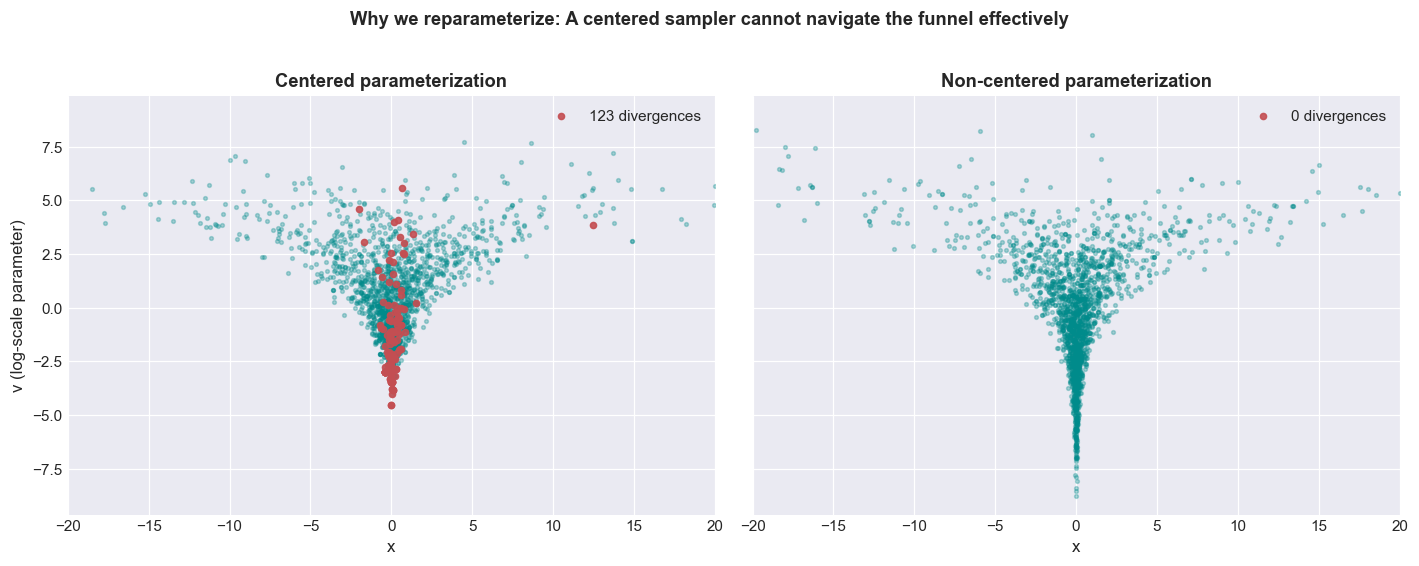

In [52]:
#@title Optional: seeing the funnel (centered vs non-centered)
# Neal's funnel:  v ~ N(0, 3^2);  x ~ N(0, exp(v/2)).  The joint (v, x) is
# funnel-shaped and a sampler working in these coordinates diverges near the
# neck. The non-centered form x = exp(v/2) * z, z ~ N(0,1), removes the pathology.
with pm.Model():
    v = pm.Normal("v", 0.0, 3.0)
    x = pm.Normal("x", 0.0, pm.math.exp(v / 2), shape=1)
    idata_c = pm.sample(1000, tune=1000, chains=2, target_accept=0.8,
                        random_seed=24, progressbar=False)

with pm.Model():
    v = pm.Normal("v", 0.0, 3.0)
    z = pm.Normal("z", 0.0, 1.0, shape=1)
    x = pm.Deterministic("x", pm.math.exp(v / 2) * z)
    idata_nc = pm.sample(1000, tune=1000, chains=2, target_accept=0.8,
                         random_seed=24, progressbar=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, idata, name in [(axes[0], idata_c, "Centered"), (axes[1], idata_nc, "Non-centered")]:
    vv = idata.posterior["v"].values.flatten()
    xx = idata.posterior["x"].values.reshape(-1)
    div = idata.sample_stats["diverging"].values.flatten()
    ax.scatter(xx[~div], vv[~div], s=6, alpha=0.3, color=PALETTE['primary'])
    ax.scatter(xx[div], vv[div], s=16, alpha=0.9, color=PALETTE['accent'],
               label=f"{int(div.sum())} divergences")
    ax.set_title(f"{name} parameterization")
    ax.set_xlabel("x")
    ax.legend(loc="upper right")
    ax.set_xlim(-20, 20)
axes[0].set_ylabel("v (log-scale parameter)")

plt.suptitle("Why we reparameterize: A centered sampler cannot navigate the funnel effectively",
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Reading the plot.** Each point is one post-warmup draw, plotted at the state the sampler visited; the red points are divergent transitions.

NUTS advances by simulating Hamiltonian dynamics with a discrete leapfrog integrator, along which total energy should be (approximately) conserved. In the narrow neck of the funnel the log-density curves so sharply that the fixed step size overshoots and the simulated energy jumps. When that energy error crosses a threshold, NUTS flags the transition as divergent, halts it, and records where it started. PyMC prints the count and stores a per-draw boolean in `trace.sample_stats["diverging"]`, which is what we colour red.

We can see that the divergences concentrate precisely where the geometry is hardest, so that region is *systematically under-sampled* and estimates there are biased. In the centered panel, all divergences pile up in the neck and you can see that the neck is not sampled as thoroughly as in the panel on the right. The non-centered panel samples from a mathematically identical distribution and yet shows zero divergences.

### Prior predictive check

**What we are trying to do.** A prior is a claim about which data points are plausible *before* seeing any of them. This check makes that claim visible: we draw parameter sets $\theta^{(s)}\sim p(\theta)$ from the priors *alone*, push each through the regression equation, and simulate solve times $\tilde{y}^{(s)}\sim p(y\mid\theta^{(s)})$ and contrast that to the actual data distribution. No observed data enters the picture here.

The aim is not to reproduce the distribution of real solve times; the priors are deliberately weak, so the prior predictive should be *broader* than reality. We are only checking that the simulated times land in a physically sane range and not somewhere absurd. If draws from the prior distribution give us solve times in microseconds or days, the data would have to do that much more work to fight against the absurd priors and possibly result in a distorted posterior.

Sampling: [alpha, beta, beta_age, beta_archive, beta_oldage, constructor_raw, day_effect_raw, sigma, sigma_constructor, sigma_skill, skill_innovations, y_obs]


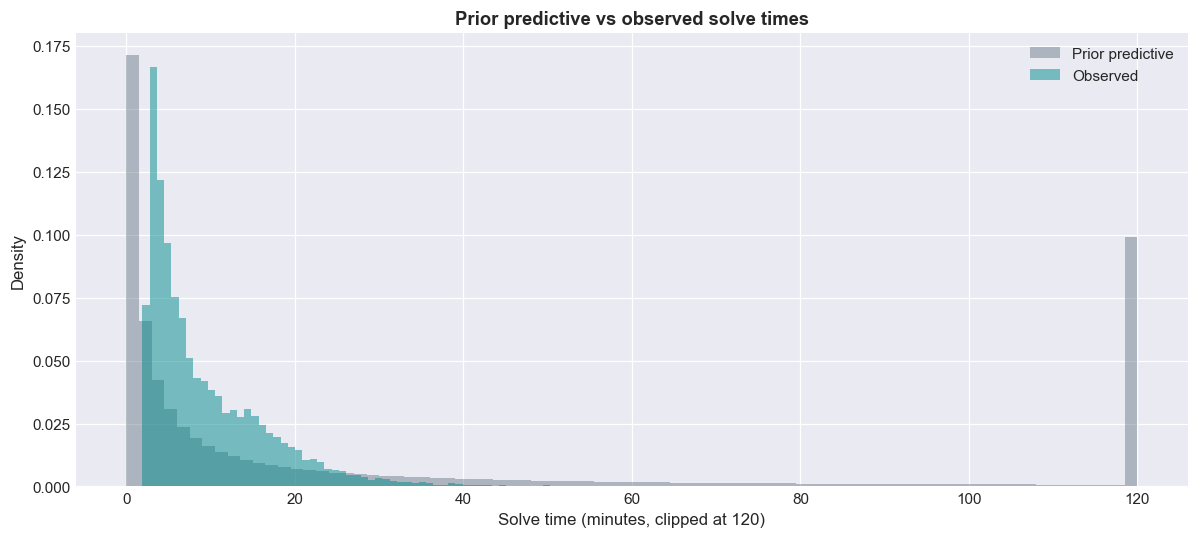

Prior predictive median:   7.5 min  (1st-99th pct: 0.01 - 8571 min)
Observed median:           6.8 min


In [53]:
#@title Prior predictive check
with crossword_model:
    idata_prior = pm.sample_prior_predictive(200, random_seed=42)

prior_pred = np.exp(idata_prior.prior_predictive["y_obs"].values.flatten()) / 60.0  # minutes
obs_minutes = np.exp(log_solve_time) / 60.0

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(np.clip(prior_pred, 0, 120), bins=80, density=True, alpha=0.5,
        color=PALETTE['muted'], label="Prior predictive")
ax.hist(np.clip(obs_minutes, 0, 120), bins=80, density=True, alpha=0.5,
        color=PALETTE['primary'], label="Observed")
ax.set_xlabel("Solve time (minutes, clipped at 120)")
ax.set_ylabel("Density")
ax.set_title("Prior predictive vs observed solve times")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Prior predictive median: {np.median(prior_pred):5.1f} min  "
      f"(1st-99th pct: {np.percentile(prior_pred, 1):.2f} - {np.percentile(prior_pred, 99):.0f} min)")
print(f"Observed median:         {np.median(obs_minutes):5.1f} min")


**What we see.** The prior predictive median is 7.5 min against an observed median of 6.8 min; the priors are centred in exactly the right neighbourhood, so the model does not start from an absurd place. At the same time the 1st&ndash;99th percentile range is enormous: from 0.01 min (well under a second) to ~8,571 min (roughly 6 days). Recall that we *want* this range to be wide - that is what "weakly informative" means. So, some width here (maybe 30 seconds - 3 hours) is a good thing but there is clearly room for improvement in making the priors sharper. Will get to it in a future iteration.

### Sampling from this Model
Now that we have specified the data generation model (the regression equation) and the priors for all parameters, we come to the estimation part where we will let the data dictate a joint posterior distribution for all parameters. The process is as follows:

*   Define $\theta = \big(\alpha,\, \sigma,\, \sigma_{\text{skill}},\, \{z^{\text{skill}}_j\},\, \text{day}_m, \beta_{\text{arch}},\, \beta_{\text{age}},\, \beta_{\text{oldage}},\, \{\beta_f\},\, \sigma_{\text{con}},\, \{z^{\text{con}}_c\}\big)$. These are all the parameters in the system - there are $1 + 1 + 1 + (W-1) + (7-1) + 1 + 1 + 1 + 2 + 1 + C = W + C + 14$ parameters in the system where $W$ is the number of weeks and $C$ is the number of constructors. We have $498$ weeks and $2024$ constructors for a total of $2536$ parameters. Note that these parameters might be combined in some way to create the terms that go into the regression. 
*   Given any $\theta$, we can evaluate $p(y_1, y_2, \dots, y_N \mid \theta)$ - i.e., the distribution of solve times given some values for all parameters. This will just be the 
$$
\begin{aligned}
p(\vec{y} \mid \theta) &= \prod_{i=1}^{N} \mathcal{N}(\log t_i \mid \mu_i, \sigma^2) \\
&\propto \exp \left[ \left( -\frac{1}{2} \sum_{i=1}^{N} \left( \frac{(\log t_i - \mu_i)^2}{\sigma^2} \right) \right) \right]
\end{aligned}
$$
*   For the same $\theta$, we can also calculate $p(\theta)$ which will be a product of the priors of all the individual components of $\theta$
*   The posterior $p(\theta \mid \vec{y})$ can now be partially evaluated because we know that $p(\theta \mid \vec{y}) \propto p(\vec{y} \mid \theta) \cdot p(\theta)$. The missing piece is the denominator $p(\vec{y}) = \int_\theta p(\vec{y} | \theta)p(\theta)d\theta$ which is very hard to evaluate since it requires integrating over this $2536$ dimensional space. However, it is also independent of $\theta$ and so needn't really be evaluated. 
*   Very crudely, we can divide the $\theta$-space into grids, evaluate $p(\vec{y} \mid \theta) \cdot p(\theta)$ at each point of the grid and we would be done. This is of course impossible in practice because of the curse of dimensionality. All Bayesian sampling methods are techniques to evaluate/approximate this posterior in computationally viable ways.
*   Rather than visit every point in the $\theta$-space, we can use $\nabla_\theta \log p(\theta \mid \vec{y})$ to decide where to visit so that we spend more time on more promising regions of the posterior. The sampler below uses an algorithm called NUTS (No U-Turn Sampler), a form of Hamiltonian Monte Carlo. Very briefly, it simulates a ball rolling frictionlessly on the surface $-\log p(\theta \mid \vec{y})$ with a random kick at the end of every trajectory. While this algorithm is similar to gradient descent, the goals are different - gradient descent tries to find the lowest point in the valley and stay there. This sampler tries to visit each region of the $\theta$-space (not just the lowest valley) *in proportion to its posterior mass*.
*   After some warm-up time (where stepsize is calibrated), the movement of the ball (i.e., all the $\theta$ values that it visits) is logged at every instance - taken together, these will trace out the posterior $p(\theta \mid \vec{y})$ from which individual posteriors can be extracted by marginalization.

In [54]:
#@title Sample from the chain

warnings.filterwarnings("ignore", category=UserWarning)
with crossword_model:
    print("Initiating MCMC sampling via NUTS. This may take 10-20 minutes...")
    trace = pm.sample(
        draws=1500, # num draws after warmup
        tune=1500, # warmup period that will be discarded
        chains=4, # 4 different starting points
        target_accept=0.95, # higher target_accept reduces the chance of divergent transitions, but increases runtime
        #nuts_sampler="nutpie",
        random_seed=42
    )
print("Sampling complete!")

Initiating MCMC sampling via NUTS. This may take 10-20 minutes...


NUTS[nutpie]: [alpha, sigma, sigma_skill, skill_innovations, day_effect_raw, beta_archive, beta_age, beta_oldage, beta, sigma_constructor, constructor_raw]


Output()

Sampling complete!


In [55]:
#@title Quick look at the outputs

warnings.filterwarnings("ignore", category=RuntimeWarning)
variable_names = list(trace.posterior.data_vars)
print("Variables found in this trace:")
print(variable_names)
print('---'*20)

print("\nTracked dimensions and coordinate lengths:")
for coord_name, coord_vals in trace.posterior.coords.items():
    print(f" -> Coordinate: '{coord_name}' | Total Elements: {len(coord_vals.values)}")
print('---'*20)

summary_vars = ["alpha", "sigma", "sigma_skill", "beta_archive",
                "beta_age", "beta_oldage", "beta", "sigma_constructor"]
print(az.summary(trace, var_names=summary_vars))

print('---'*20)
n_div = int(trace.sample_stats["diverging"].sum())
print(f"Divergences: {n_div}")

print('---'*20)
# Worst-case convergence across ALL params, incl. the 2000+ constructor effects
summ = az.summary(trace).apply(pd.to_numeric, errors="coerce")
print(f"Max r_hat:   {summ['r_hat'].max()}")
print(f"Min ess_bulk: {summ['ess_bulk'].min()}")
print(f"Min ess_tail: {summ['ess_tail'].min()}")

print('---'*20)
flagged = summ[(summ['r_hat'] > 1.01) | (summ['ess_bulk'] < 400)]
print(flagged if len(flagged) else "All parameters pass r_hat<=1.01 and ess_bulk>=400.")


Variables found in this trace:
['alpha', 'skill_innovations', 'day_effect_raw', 'beta_archive', 'beta', 'constructor_raw', 'sigma', 'sigma_skill', 'beta_age', 'beta_oldage', 'sigma_constructor', 'ability', 'day_effect', 'fustiness', 'constructor_effect']
------------------------------------------------------------

Tracked dimensions and coordinate lengths:
 -> Coordinate: 'chain' | Total Elements: 4
 -> Coordinate: 'draw' | Total Elements: 1500
 -> Coordinate: 'skill_innovations_dim_0' | Total Elements: 497
 -> Coordinate: 'day_effect_raw_dim_0' | Total Elements: 6
 -> Coordinate: 'features' | Total Elements: 2
 -> Coordinate: 'constructors' | Total Elements: 2024
 -> Coordinate: 'solve_weeks' | Total Elements: 498
 -> Coordinate: 'days_of_week' | Total Elements: 7
 -> Coordinate: 'publish_years' | Total Elements: 33
------------------------------------------------------------
                      mean       sd eti89_lb eti89_ub  ess_bulk  ess_tail  \
alpha                5.831    0.

### How to read the results
*   Think of **target_accept** as a measure of the accuracy of the underlying physics simulator. If we set it to higher values, we demand that the physics is very accurate which forces the model to use smaller step sizes. This in turn reduces risk of divergence but will increase runtime. Smaller stepsizes might be needed in *hierarchical* models where some parameters influence the value of other parameters (and in the process introduce funnels in the posterior like we discussed above)
*   We need **4 chains** not just for averaging but also for confidence in the final posterior. Ideally, all 4 chains should converge to the same posterior which can be measured ($\hat{r}$ should be $\leq 1.01$)
*   **ess_bulk** is the effective sample size which will be strictly less than the number of draws since the draws are highly correlated. **ess_tail** is the same quantity for the confidence intervals (computed when the sampler visited the far flung regions of the posterior)

### Does the fitted model reproduce the data?

**What we are trying to do.** Convergence diagnostics ($\hat{r}$, ESS) tell us the sampler *explored the posterior* well; they say nothing about whether the *model* is any good. Let  ask the next question &mdash; does the fitted model actually describe the data, and how accurately would it predict?

*   **Posterior predictive check (PPC)** - does the model regenerate data that looks like what we observed? Does it capture day-to-day variations well?
*   **LOO** - how accurately does the model predict a held-out solve? True leave-one-out CV would refit the model $N=11{,}661$ times, each time holding out one solve and scoring the prediction on it. PSIS-LOO avoids that by reweighting the *single* full-data posterior to approximate each held-out fit, using importance weights $\propto 1/p(y_i\mid\theta)$. The result, `elpd_loo`, is the summed log predictive density on held-out data (higher = better) &mdash; the number you compare across competing models. The reweighting is trustworthy only if no single observation dominates its weights; the **Pareto-$k$** statistic measures that per observation ($k\le 0.7$ good, $>0.7$ unreliable).


Sampling: [y_obs]


Output()

Output()

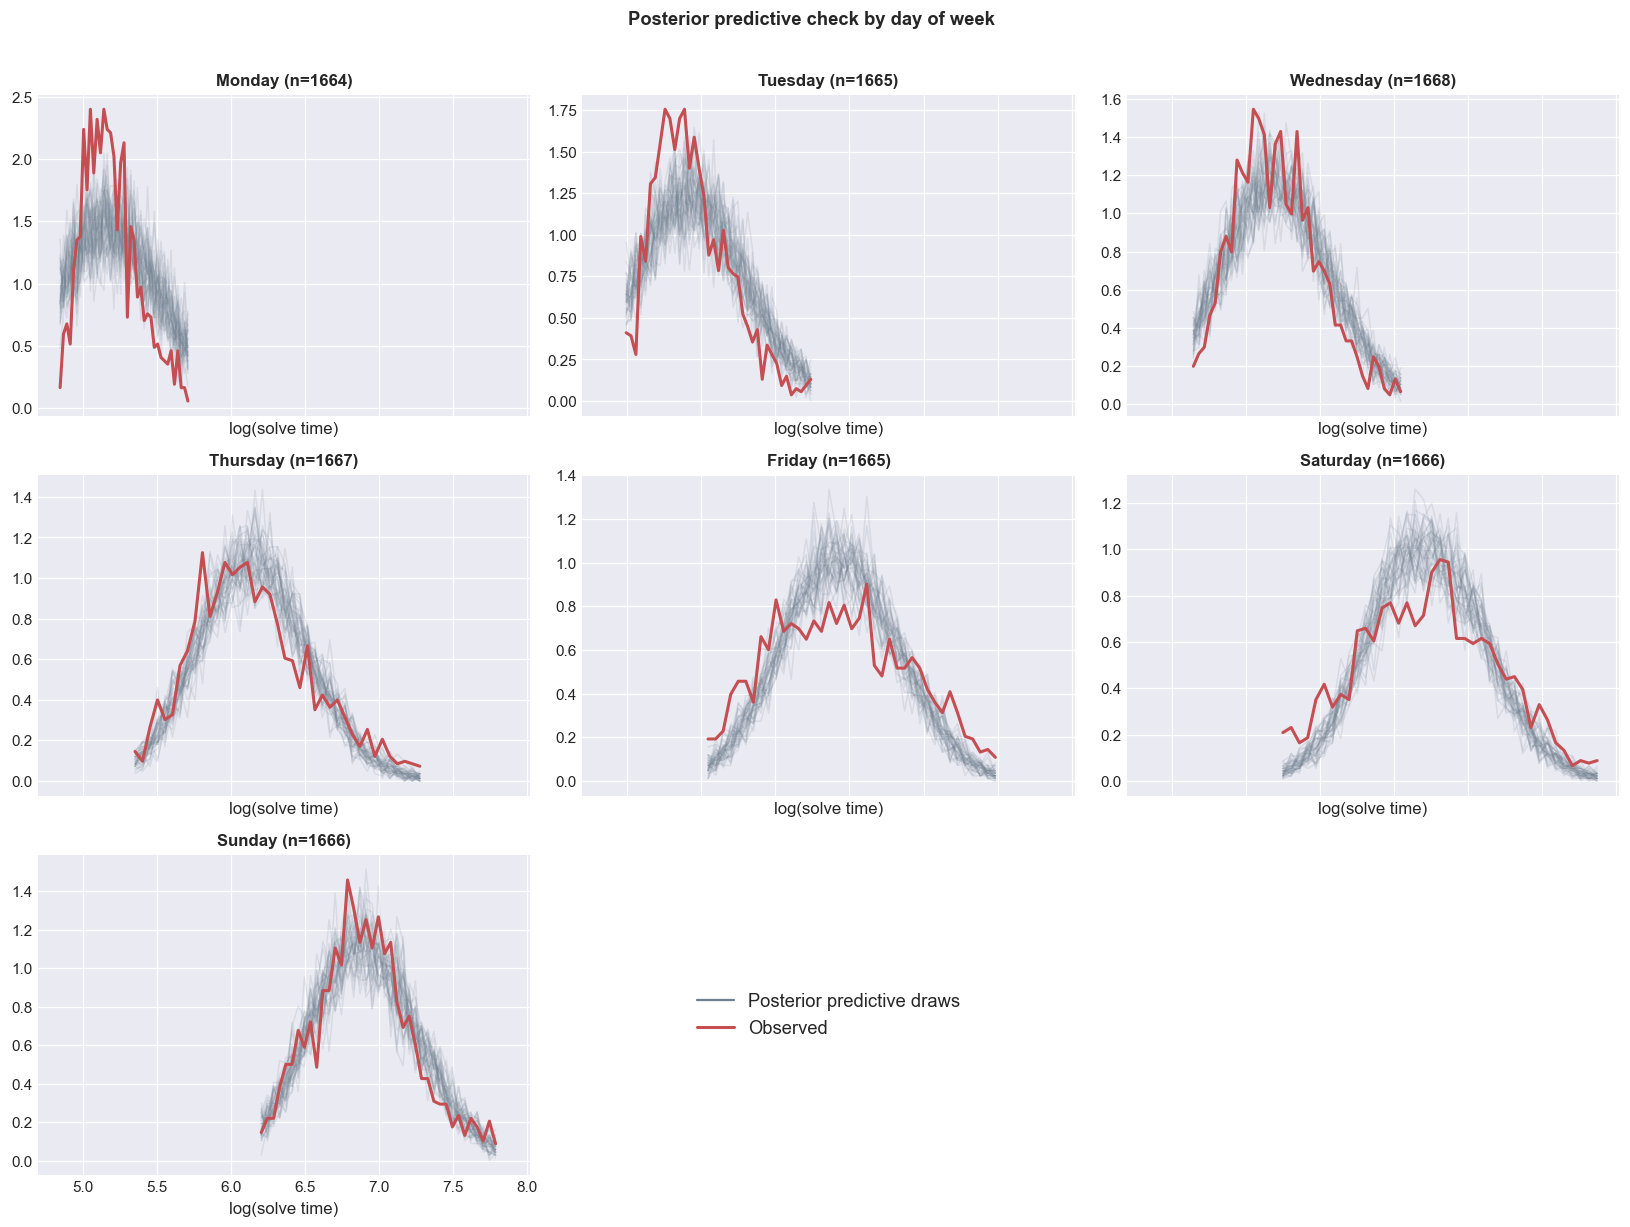

In [56]:
#@title Posterior predictive check by day of week
# Reuses the posterior_predictive group added by the pooled PPC cell above.
# posterior predictive replicates: shape (N_obs, N_samples)
with crossword_model:
    pm.sample_posterior_predictive(trace, extend_inferencedata=True, random_seed=42)
    pm.compute_log_likelihood(trace)
    
pp = trace.posterior_predictive["y_obs"].stack(sample=("chain", "draw")).values
obs = log_solve_time

edges = np.linspace(obs.min(), obs.max(), 60)
centers = 0.5 * (edges[:-1] + edges[1:])
rng = np.random.default_rng(42)
draw_idx = rng.choice(pp.shape[1], size=60, replace=False)


pp_days = trace.posterior_predictive["y_obs"].stack(sample=("chain", "draw")).values  # (N_obs, S)
rng = np.random.default_rng(0)
sel = rng.choice(pp_days.shape[1], size=40, replace=False)

fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=True)
for d_idx, day_name in enumerate(puzzle_day_order):
    ax = axes.flat[d_idx]
    mask = (day_of_week_idx == d_idx)
    lo, hi = np.percentile(log_solve_time[mask], [1, 99])
    edges = np.linspace(lo, hi, 40)
    centers = 0.5 * (edges[:-1] + edges[1:])
    for j in sel:
        h, _ = np.histogram(pp_days[mask, j], bins=edges, density=True)
        ax.plot(centers, h, color=PALETTE['muted'], alpha=0.15, lw=1)
    h_obs, _ = np.histogram(log_solve_time[mask], bins=edges, density=True)
    ax.plot(centers, h_obs, color=PALETTE['accent'], lw=2)
    ax.set_title(f"{day_name} (n={int(mask.sum())})", fontsize=11)
    ax.set_xlabel("log(solve time)")

axes.flat[7].axis('off')
axes.flat[8].axis('off')
axes.flat[7].legend(handles=[
    mlines.Line2D([0], [0], color=PALETTE['muted'], lw=1.5, label='Posterior predictive draws'),
    mlines.Line2D([0], [0], color=PALETTE['accent'], lw=2, label='Observed'),
], loc='center', fontsize=12)
plt.suptitle("Posterior predictive check by day of week", y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()


The observed density (red) sits squarely inside the cloud of posterior-predictive replicates (grey): the model regenerates data with the right location and spread, so the log-normal likelihood plus additive structure is an adequate description.

But maybe the model only gets the overall shape right and has difficulty predicting any given day well? The LOO analysis below answers this objection.

### Leave One Out using Pareto Smoothed Importance Sampling (PSIS - LOO)

A gold standard for measuring "goodness of fit" is to do a "leave one out" cross-validation. If we have to do it from first principles, we have to repeat the Bayesian modeling $N = 11,661$ times which would take thousands of hours. Fortunately, there is a clever shortcut in the Bayesian world that allows us to do this.

Let us say we train a model by holding out the $i$th observation. Let $\theta \mid y_{-i}$ be the model trained on all observations other than $y_i$. The leave-one-out model's performance would be how closely this model can reproduce $y_i$ despite having never seen it. Define this performance as
$$
\begin{aligned}
P(y_i \mid y_{-i}) &= E_{\theta \sim p(\theta \mid y_{-i})} \left[ P(y_i \mid \theta) \right] \\
&= \int p(y_i \mid \theta) \cdot p(\theta \mid y_{-i}) d\theta
\end{aligned}
$$
The problem is we cannot compute $P(\theta \mid y_{-i})$ - this involves building $11,661$ Bayesian models, one for each $i$. What can we do instead?

A key piece of intuition is that we know a distribution that is *very close* to $P(\theta \mid y_{-i})$ and that we do know how to sample from, namely $P(\theta \mid y)$, i.e., the model trained on *all* observations. Given that there are thousands of observations, holding one of them out should not impact the trained model too much and these values should be close. This is a classic use-case of **Importance Sampling**, a sleight of hand that lets you compute expectation over a "tough" distribution by altering it into an expectation of a slightly modified variable over an "easier" distribution.

Importance sampling uses a seemingly simple looking transformation

$$
\begin{aligned}
E_P [A] &= \int p(x) A(x) dx \\
&= \int q(x) \left( \frac{p(x)}{q(x)} \right) A(x) dx \\
&= E_Q \left[A \cdot \frac{P}{Q} \right]
\end{aligned}
$$

In our case, the hard distribution $P(x)$ is $p(\theta \mid y_{-i})$, the easy distribution $Q(x)$ is $p(\theta \mid y)$ and the LOO metric becomes

$$
\begin{aligned}
P(y_i \mid y_{-i}) &= \int p(y_i \mid \theta) \cdot p(\theta \mid y_{-i}) d\theta \\
&= \int p(y_i \mid \theta) \left[ \frac{p(\theta \mid y_{-i}}{p(\theta \mid y)} \right] p(\theta \mid y) d\theta \\
&= E_{\theta \sim p(\theta \mid y)} \left[ p(y_i \mid \theta) w_i (\theta) \right]
\end{aligned}
$$
where $w_i(\theta)$ is the importance weight defined as $$w_i(\theta) = \frac{p(\theta \mid y_{-i})}{p(\theta \mid y)}$$

If we can find a tractable formula for $w_i(\theta)$, we can calculate this expectation as it is over a posterior that is known to us from the MCMC samples. Let us try to quantify how $P(\theta \mid y)$ is related to its close cousin $p(\theta \mid y_{-i})$. Using Bayes rule, we can write

$$
\begin{aligned}
p(\theta \mid y) &= p(\theta \mid y_i, y_{-i}) \\
&= \frac{p(y_i \mid \theta, y_{-i}) \cdot p(\theta \mid y_{-i})}{p(y_i \mid y_{-i})}
\end{aligned}
$$

Therefore, the importance weight can be written as
$$
\begin{aligned}
w_i(\theta) &= \frac{p(\theta \mid y_{-i})}{p(\theta \mid y)} \\
&= \frac{p(y_i \mid y_{-i})}{p(y_i \mid \theta, y_{-i})}
\end{aligned}
$$

Given all the parameters $\theta$, $y_i$ and $y_{-i}$ are independent. Therefore, we can simplify $p(y_i \mid \theta, y_{-i})$ as $p(y_i \mid \theta)$. Putting this back into the expression for importance weight, we get

$$
\begin{aligned}
w_i(\theta) &= \frac{p(y_i \mid y_{-i})}{p(y_i \mid \theta)} \\
&\propto \frac{1}{p(y_i \mid \theta)}
\end{aligned}
$$

Note that leaving the numerator in there defeats the whole purpose of these manipulations because $p(y \mid y_{-i})$ is the very quantity that we are trying to estimate. But, it is independent of $\theta$ and we can settle for the next best thing which is a weight term that is *not exact* (it is missing a proportionality constant) but is *easy to compute* (it is just tbe likelihood of $y_i$).

Putting this expression for the importance weight back into the main equation and normalizing out the scaling constant, we get

$$
\begin{aligned}
P(y_i \mid y_{-i}) &= \frac{E_{\theta \sim p(\theta \mid y)} \left[ p(y_i \mid \theta) w^{*}_i (\theta) \right]}{E_{\theta \sim p(\theta \mid y)} w^{*}_i (\theta)} \\
&= \frac{E_{\theta \sim p(\theta \mid y)} \left[ p(y_i \mid \theta) \frac{1}{p(y_i \mid \theta)} \right]}{E_{\theta \sim p(\theta \mid y)} \frac{1}{p(y_i \mid \theta)}} \\
&= \left( E_{\theta \sim p(\theta \mid y)} \left[ \frac{1}{p(y_i \mid \theta)} \right] \right)^{-1}
\end{aligned}
$$

What this says, in plain English, is that the inverse of the average LOO fit for the $i^{\text{th}}$ observation is expectation of the inverse of the likelihood of $y_i$ where, crucially, the expectation is taken over the model trained on *all* observations. In other words, despite $y_i$ being part of the model, we can use our posteriors to simulate a world where $y_i$ was held out!!!

Mechanically, the way we would do this is to draw parmeters from the joint posterior, calculate the inverse of the likelihood of $y_i$ under each draw, average it out, and invert the average once again. Or, in the log domain

$$
\begin{aligned}
\text{ELPD} &= \sum_i \log p(y_i \mid y_{-i}) \\
&= - \sum_i \log \left( E_{\theta \sim p(\theta \mid y)} \left[ \frac{1}{p(y_i \mid \theta)} \right] \right)
\end{aligned}
$$

ELPD offers a convenient way to compare two different Bayesian models. The model with the higher ELPD makes better OOB predictions. In practice, this formula with all of its inverses is prone to blowing up. To avoid this numerical issue,  PSIS fits a Pareto distribution to the weight tail and caps it — that's the 'PS,' and the Pareto-kk
k is the fitted tail index. This index being large ($> 0.7$) is a sign that the distribution struggled to fit the weights, i.e., some of the weights blew up and are worth a closer investigation.

In [57]:
#@title LOO (reuses the existing trace)

# LOO (leave-one-out CV via PSIS). Needs the log_likelihood group added above.
try:
    print(az.loo(trace))
except Exception as e:
    print(f"(LOO skipped: {type(e).__name__}: {e})")

Computed from 6000 posterior samples and 11661 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2368.83    83.80
p_loo      399.07        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     11661  100.0%
   (0.70, 1]   (bad)          0    0.0%
    (1, Inf)   (very bad)     0    0.0%



`elpd_loo` $= -2369.0$ (SE 84) with 100% of Pareto-$k$ values $\le 0.70$ &mdash; had any of the weights blown up, the scale parameter for the Pareto fit would have become larger signalling that. Here, the importance-sampling approximation is reliable for all 11,661 observations, so there are no over-influential points and this `elpd` can be trusted when comparing against alternative models.

Another interesting application of this loo is the notion of effective parameters. Very roughly, it calculates the difference between ELPD and LPD (predicting $y_i$ by using a model that has seen $y_i$, i.e., $E_{\theta \sim p(\theta \mid y)} [p(y_i \mid \theta)])$. If this difference is $0$ for some $i$, it means the parameters associated with that observation have been shrunk to $0$ by the model (and so, removing that observation did not hurt the model in any way). Therefore, summing up this difference across all $i$ gives some idea of how many parameters remain "unshrunk". In our case, around $400$ of the $\approx 2,500$ parameters haven't been aggressively shrunk to $0$ which makes sense.

**Bayesian Black Magic** is what this feels like. In any other modeling framework (say random forests), there is no shortcut to computing LOO validations other than building the model $N$ times. All this math aside, how are we able to sidestep this in the Bayesian world? The answer is that we pay an incredibly steep training cost upfront during the MCMC sampling phase. Compare the time it would take to build a random forest on $11,661$ observations against what it takes here. We can bypass retraining $N$ times because you spent the computational capital to map a full, continuous probability distribution (not just a set of parameters) and this distribution allows us to interrogate it in many ways.